## Matched filtering for tau

WORK IN PROGRESS: Build noise statistics
- bring tau function to external script
- find a way to get faster function. 


TO DO: CHECKS: <br>
Compute $\tau_{rs}$ multiple times and build distribution: noise should give bias oscillating around zero, not systematic bias in one direction. 
- study differnce in Cls computed from map 1) sliced directly on computation  2) computed to lmax and sliced later  --> study impact on tau results
- check that all Cls are sliced with lmax at computationa and not after

IDEAS: 
- find method to determine optimal ell range for matched filtering: try with colormap


EVENTUALLY: 
- bring 4 plots function to external script
- extend to other planck channels
- add funciton to compute FWHM of beam (and maybe also beam radius) -- could add to the read_beam function


QUESTIONS: 
- how to account for uncertainties from the template when computing sigma_tau?
- Noise subtraction case:subtracted from Cl_cross --> Do I need to also modify the covariance=Cls_data to account for this? How to account for this?  
- How to perform noise subtraction at the map level?
- is the method to cancel out the bias legit?

IDEAS: 
- if we establish that different templates bias in different wasy we could use this in some way


ATTEMPTS:
- tried to re-convolve with gaussian beam but the beam function remains multiplied in the final result. --> IDEA: see if it works anyway to recover tau since the template is the same (maybe works better sicne noise is not enhanced)

## Defined quantities: 

| Variable | Description | Derivied quantities|
|----------|-------------|------------|
| `nside`   | same for all CMB and beam maps |
| `lmax`    | for maps Cls, derived from nside| `ll` array [0-lmax]|
| `lmax_PLA`| for theoretical PLA Cls |`llPLA` array [2-lmax_PLA] |
| `tau_th`  | input value for resonant scattering optical depth |  `tau_arr` [0-lmax], `tau_arrPLA` [2-lmax_PLA] |
| `lmax_beam`    | for deconvolved maps| `ll_cut` array [0-lmax_beam]|
| `sigma_pix30`| $\sigma_N [\mu K]$ noise in T-CMB units, scales to pixel  |   |






In [1]:
#%matplotlib widget
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import importlib
import os
import pandas as pd

import functions_rot as frot
import functions_beams as fbeams
import functions_tau as ftau

from matplotlib.colors import LogNorm
from tabulate import tabulate


In [2]:
importlib.reload(ftau)
importlib.reload(fbeams)
importlib.reload(frot)

<module 'functions_rot' from '/home/evanetti/BEAMS/beams_code/functions_rot.py'>

In [3]:
#### READ FILES ####
dir_="/home/evanetti/BEAMS/code_input/"

# original CMB maps
fcmb='convolved_maps/map0.fits'
map_cmb=hp.fitsfunc.read_map(dir_+fcmb, field=0)
fxi='convolved_maps/map_xi.fits'
map_xi=hp.fitsfunc.read_map(dir_+fxi, field=0)

# convolved CMB maps 
f0="convolved_maps/map0_convolved_map1024_fast_mpi.fits"
f1='convolved_maps/map_xi_convolved_map1024_fast_mpi.fits'
map0=hp.fitsfunc.read_map(dir_+f0, field=0) #30 GHz
map1=hp.fitsfunc.read_map(dir_+f1, field=0) #70 GHz

# beam maps
beam0, vc0 = fbeams.read_beam('30GHz', printtext=False)  # alrady normalized
beam1, vc1 = fbeams.read_beam('70GHz', printtext=False)
print('\n\n')

#Cls from PLA: 
fnamePLA='COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt' #read Cls from PLA - checked that this is lensed
lPLA, DlPLA = np.genfromtxt(dir_+fnamePLA, dtype="float", comments="#", usecols=(0,1), unpack=True)
normClPLA=lPLA*(lPLA+1)/(2*np.pi)
ClPLA=DlPLA/normClPLA

# SET Nside for maps:
nside0=hp.get_nside(map0) 
nside1=hp.get_nside(map1)
nside_beam0=hp.get_nside(beam0)
nside_beam1=hp.get_nside(beam1)

nside=min(nside0, nside1, nside_beam0, nside_beam1)
nside_arr=np.array([nside0, nside1, nside_beam0, nside_beam1])
if len(set(nside_arr)) > 1: #set(array) removes duplicates --> this checks if there is a different element 
    print('WARNING: maps have different Nside!! Downgrading to lower resolution map: nside = ', nside)
    print('Nsides=', nside_arr)
    map0=hp.pixelfunc.ud_grade(map0, nside)
    map1=hp.pixelfunc.ud_grade(map1, nside)
    beam0=hp.pixelfunc.ud_grade(beam0, nside)
    beam1=hp.pixelfunc.ud_grade(beam1, nside)
else: 
    print(f'Common Nside = {nside}')

pixArea_rad = hp.nside2pixarea(nside)

### lmax corresponding to nside: 
lmax = 3*nside-1 #for maps
print('lmax for maps: ', lmax, '\t(corresponding to Nside)')
ll=np.arange(lmax+1)

lmax_PLA=int(lPLA[-1])
print('\nlmax for PLA Cls: ', lmax_PLA)

Normalization factor =  0.9902671663946919
Normalized beam integral =  1.0
Normalization factor =  0.9910121240031213
Normalized beam integral =  0.9999999999999998



Common Nside = 1024
lmax for maps:  3071 	(corresponding to Nside)

lmax for PLA Cls:  2508


In [4]:
#### NORMalization for Cls or Dls plots 
def getnorm(option, l):
    if option=='Cls': #noise subtraction attempts 
        norm=1.
        ylabel=r'$C_\ell\,[\mu K^2]$'
    elif option=='Dls':
        norm=l*(l+1)/(2*np.pi)
        ylabel=r'$\ell(\ell+1)/2\pi\,\,C_\ell\,[\mu K^2]$'

    return norm, ylabel

In [5]:
def compare_arr(arr1, arr2, tolerance=1e-7):
    diff=arr1-arr2
    print("min difference:", np.nanmin(diff))
    print("max difference:", np.nanmax(diff))
    equal=np.array_equal(arr1, arr2)
    print('arrays are exacly equal: ', equal)

    close=np.allclose(arr1, arr2, atol=tolerance) # rtol=1e-5  #atol=absolute tolerance, rtol=relative tolerance
    print(f'arrays difference within {tolerance}: {close}\n')
    
    return 0



In [6]:
## tau_l for theoretical maps
tau_th=1e-3
tau_arr, tau_arr2 = ftau.get_tau_arr(tau_th, lmax, plot=False)
tau_arrPLA=tau_arr[2:lmax_PLA+1]
tau_arr2PLA=tau_arr2[2:lmax_PLA+1]

lcut_tau =  30


## Beams

normalized so that $C_\ell^{beam}=1$ at large scales: <br>
beam map normalized to 1: $\sum_{pix} B_{pix} \Delta\Omega_{pix}[\rm{rad}^2]=1$   $\qquad$  should be normalized to $4\pi$ to get Cls=1<br>
further multiply: $C_l^{\rm{beam}}=4\pi \cdot$ hp.anafast(beam_map)

In [7]:
#### CHECK beam norm
print('normalized beam = ', np.sum(beam0)*pixArea_rad, np.sum(beam1)*pixArea_rad)

lmax_beam=700 #CUT higher beam multipoles
print('\nCut beam Cls at lmax_beam = ', lmax_beam)
Cls_beam0=hp.anafast(beam0, lmax=lmax_beam, use_pixel_weights=True)*4*np.pi  # symmetrized beams, up to lmax
Cls_beam1=hp.anafast(beam1, lmax=lmax_beam, use_pixel_weights=True)*4*np.pi 
ll_cut=ll[:lmax_beam+1]


print('Check that beam Cls are =1 on large scales')
print(f'                l={ll[0]}           l={ll[5]}               l={ll[10]}')
print('beam0: ', Cls_beam0[0], Cls_beam0[5], Cls_beam0[10] )
print('beam1: ', Cls_beam1[0], Cls_beam1[5], Cls_beam1[10] )


normalized beam =  1.0 0.9999999999999998

Cut beam Cls at lmax_beam =  700
Check that beam Cls are =1 on large scales
                l=0           l=5               l=10
beam0:  0.9999999983519358 0.9995113081889576 0.9982094225433674
beam1:  0.9999999999904328 0.9999161790156882 0.9996926958755952


In [8]:
#get beam FWHM
fwhm0=fbeams.beam_FWHM(beam0, vc0)
fwhm1=fbeams.beam_FWHM(beam1, vc1)
FWHM=max(fwhm0, fwhm1)
print('common convolution FWHM: ', FWHM)

FWHM: 0.0093 rad = 0.53 deg
FWHM: 0.0038 rad = 0.22 deg
common convolution FWHM:  0.009283645428371342


In [9]:
# Maps for noise-only case: convolve with symmetrized beams
map0symm=hp.sphtfunc.smoothing(map_cmb, beam_window=np.sqrt(Cls_beam0), lmax=lmax_beam) 
map1symm=hp.sphtfunc.smoothing(map_xi, beam_window=np.sqrt(Cls_beam1), lmax=lmax_beam)

## Beam residuals

In [142]:
from sympy.physics.wigner import clebsch_gordan
from sympy.physics.wigner import wigner_3j

In [45]:
alm0 = hp.map2alm(map0, lmax=lmax_beam, use_pixel_weights=True) 
alm1 = hp.map2alm(map1, lmax=lmax_beam, use_pixel_weights=True)
alm_cmb=hp.map2alm(map_cmb, lmax=lmax_beam, use_pixel_weights=True)

## Noise

In [10]:
nu2=np.array([   30,     44,     70,     100,    143,    217,    353,    545,    857  ]) #planck frequency channels 
sigmaN_pix, NCls_levels = ftau.convert_noise_sigma(nu2, nside, print_opt=True)  #noise sigma [μK⋅pix] in CMB T-units, amplitude of Noise Cls 
sigmaN_alms=np.sqrt(pixArea_rad)*sigmaN_pix  # or sigmaN_alms=np.sqrt(NCls_levels)

f[GHz]	σ_RJ[μK⋅deg]	σ_CMB[μK⋅deg]	σ_CMB[μK⋅pix]	 noiseCls level[μK²]
30 	2.450 		 2.508 		43.793		1.915e-03
44 	2.570 		 2.701 		47.176		2.223e-03
70 	3.080 		 3.490 		60.959		3.711e-03
100 	1.000 		 1.287 		22.473		5.044e-04
143 	0.333 		 0.551 		9.619		9.240e-05
217 	0.261 		 0.781 		13.640		1.858e-04
353 	0.198 		 2.557 		44.662		1.992e-03
545 	0.086 		 13.680 		238.910		5.700e-02
857 	0.032 		 502.570 		8777.275		7.694e+01


In [11]:
sigmaN0=sigmaN_pix[0]
sigmaN1=sigmaN_pix[2]
level_Clsnoise0=NCls_levels[0]
level_Clsnoise1=NCls_levels[2]
level_Clsnoise_diff=level_Clsnoise1+level_Clsnoise0  #expected diff map noise level

sigmaN_alms0=sigmaN_alms[0]
sigmaN_alms1=sigmaN_alms[2]

In [12]:
# deconvolved noise levels 
level_Clsnoise0_dec=level_Clsnoise0/Cls_beam0
level_Clsnoise1_dec=level_Clsnoise1/Cls_beam1
level_Clsnoise_diff_dec=level_Clsnoise0_dec+level_Clsnoise1_dec

In [13]:
#CHECK: that noise alms are generated correctly: 
almsN0=ftau.get_noise_alm(sigmaN_alms0, lmax_beam, seed=12)
almsN1=ftau.get_noise_alm(sigmaN_alms1, lmax_beam, seed=56) 

ClsN0= hp.alm2cl(almsN0)
ClsN1= hp.alm2cl(almsN1)
print('CHECK noise alms: ')
print(f'ClsN0 avg = {np.mean(ClsN0):.4e}, expected = {level_Clsnoise0_dec[0]:.4e}, diff= {np.mean(ClsN0)-level_Clsnoise0_dec[0]:.4e}')
print(f'ClsN1 avg = {np.mean(ClsN1):.4e}, expected = {level_Clsnoise1_dec[0]:.4e}, diff= {np.mean(ClsN1)-level_Clsnoise1_dec[0]:.4e}')

CHECK noise alms: 
ClsN0 avg = 1.9101e-03, expected = 1.9153e-03, diff= -5.2593e-06
ClsN1 avg = 3.6965e-03, expected = 3.7111e-03, diff= -1.4621e-05


## Optimal $\ell$ range

NOTA: expending ell range to higher ell makes distributions of sigmas deviate between templates  

TO DO: write functions that returns only the optimal range (with optional plots to show it)

In [14]:
importlib.reload(ftau)

<module 'functions_tau' from '/home/evanetti/BEAMS/beams_code/functions_tau.py'>

In [69]:
def bestrange_MSE(tau_grid, sigma_grid, lmin_arr, lmax_arr, tau_in=1.0,printopt=False):
    """
    Find the N multipole ranges [lmin, lmax] that minimize mean squared error MSE = bias² + sigma².

    Args:
        tau_grid, sigma_grid: 2D array with matched filter results for every (lmin,lmax)
        lmin_arr, lmax_arr: 1D array of all analyzed balues for lmin, lmax
        tau_in: true value of tau
    Returns: 
        dict with keys 'tau', 'bias', 'sigma', 'MSE', 'lmin', 'lmax',
        each a 1D array of length Nbest, sorted by ascending MSE
    """
    Nbest=20
    lmin_grid, lmax_grid = np.meshgrid(lmin_arr, lmax_arr, indexing='ij')

    tau_flat   = tau_grid.ravel()
    sigma_flat = sigma_grid.ravel()
    lmin_flat  = lmin_grid.ravel()
    lmax_flat  = lmax_grid.ravel()

    # Mask invalid pairs where lmin >= lmax
    valid = lmin_flat < lmax_flat
    tau_flat   = tau_flat[valid]
    sigma_flat = sigma_flat[valid]
    lmin_flat  = lmin_flat[valid]
    lmax_flat  = lmax_flat[valid]

    #compute Mean Squared Error (MSE) = bias² + sigma²
    bias_flat = tau_flat - tau_in
    MSE_flat  = sigma_flat**2 + bias_flat**2
    idx_best = np.argsort(MSE_flat)[:Nbest]  ## get index for lowest MSE values
    idx0=idx_best[0]

    if printopt:
        print(f'lmin={lmin_flat[idx0]}, lmax={lmax_flat[idx0]}\t τ=({tau_flat[idx0]:.6f}±{sigma_flat[idx0]:.6f})\tMSqE={MSE_flat[idx0]:.6f}\tσ_dist={(tau_flat[idx0]-tau_in)/sigma_flat[idx0]:.6f}')

    return {
        'tau':   tau_flat[idx_best],
        'sigma': sigma_flat[idx_best],
        'MSqE':   MSE_flat[idx_best],
        'lmin':  lmin_flat[idx_best].astype(int),
        'lmax':  lmax_flat[idx_best].astype(int),
    }


In [16]:
def bestrange_general(grid, lmin_arr, lmax_arr, bestvalue, printopt=False): 
    lmin_grid, lmax_grid = np.meshgrid(lmin_arr, lmax_arr, indexing='ij')
    arr_flat=grid.ravel()
    lmin_flat  = lmin_grid.ravel()
    lmax_flat  = lmax_grid.ravel()
    #idx_best = np.argsort(np.absolute(arr_flat-bestvalue))[0]  #minimize difference with best value
    idx_best = np.nanargmin(np.absolute(arr_flat-bestvalue))  #alternative way to get index of minimum difference

    lmin_best=lmin_flat[idx_best]
    lmax_best=lmax_flat[idx_best]
    arr_best=arr_flat[idx_best]

    if printopt:
        print(f" Best range: lmin={lmin_best}, lmax={lmax_best} ({lmax_best - lmin_best + 1} multipoles), best_value={arr_best:.4e}")
    return lmin_best, lmax_best, idx_best


In [75]:
def plot_tau_grid(tau_grid, sigma_grid, lmin_arr, lmax_arr):
    
    bias_grid=tau_grid-1.
    sigmadist_grid=bias_grid/sigma_grid
    MSqE_grid=sigma_grid**2+bias_grid**2 

    MSqE_flat  = MSqE_grid.ravel()
    sigmadist_flat  = sigmadist_grid.ravel()
    tau_flat  = tau_grid.ravel()
    sigma_flat  = sigma_grid.ravel()

    #plot options 
    cbar_height=0.6

    fig, axes = plt.subplots(2, 2, figsize=(15, 6))
    axes = axes.ravel() 

    # MSE 
    axes[0].set_title(r'MSE$^2$', fontsize=20)
    vmax0=np.min(np.array([np.nanmax(MSqE_flat), 0.01]))
    im0 = axes[0].imshow(MSqE_grid, origin='lower', cmap='inferno_r', norm=LogNorm(vmin=np.nanmin(MSqE_grid), vmax=vmax0   )) 
    print(vmax0)
    plt.colorbar(im0, ax=axes[0], shrink=cbar_height, aspect=10)
    lmin0, lmax0, idx0 =bestrange_general(MSqE_grid, lmin_arr, lmax_arr, bestvalue=0.)
    #axes[0].scatter(lmax0, lmin0, marker='*', s=200, c='lime', edgecolors='green', zorder=10) #SELECTED best lmin,lmax
    #axes[0].annotate( f'({lmin0}, {lmax0})', xy=(lmax0, lmin0), xytext=(-55, 10), textcoords='offset points', color='lime', fontsize=12 , fontweight='bold')
    print(f'MSE best: \tlmin={lmin0}, lmax={lmax0} \tτ=({tau_flat[idx0]:.6f}±{sigma_flat[idx0]:.6f}) \tMSE={MSqE_flat[idx0]:.6f} \tσ-dist={sigmadist_flat[idx0]:.6f}')

    # sigma-dist
    delta=1.
    axes[1].set_title(r'$\sigma-$distance', fontsize=20)
    im1 = axes[1].imshow(sigmadist_grid, origin='lower', cmap='RdBu', vmin=-delta, vmax=delta  )
    plt.colorbar(im1, ax=axes[1], shrink=cbar_height, aspect=10)
    lmin1, lmax1, idx1 =bestrange_general(sigmadist_grid, lmin_arr, lmax_arr, bestvalue=0.)
    axes[1].scatter(lmax1, lmin1, marker='*', s=200, c='lime', edgecolors='green', zorder=10) #SELECTED best lmin,lmax
    axes[1].annotate( f'({lmin1}, {lmax1})', xy=(lmax1, lmin1), xytext=(5, 5), textcoords='offset points', color='lime', fontsize=12 , fontweight='bold')
    print(f'σ-dist best: \tlmin={lmin1}, lmax={lmax1} \tτ=({tau_flat[idx1]:.6f}±{sigma_flat[idx1]:.6f}) \tMSE={MSqE_flat[idx1]:.6f} \tσ-dist={sigmadist_flat[idx1]:.6f}')

    # TAU: 
    tau_th=1.
    delta=0.25
    axes[2].set_title(r'$\tau_{\rm{rs}}$', fontsize=20)
    im2 = axes[2].imshow(tau_grid, origin='lower', cmap='RdBu', vmin=tau_th-delta, vmax=tau_th+delta)
    plt.colorbar(im2, ax=axes[2], shrink=cbar_height, aspect=10) 
    lmin2, lmax2, idx2 =bestrange_general(tau_grid, lmin_arr, lmax_arr, bestvalue=tau_th)
    axes[2].scatter(lmax2, lmin2, marker='*', s=200, c='lime', edgecolors='green', zorder=10) #SELECTED best lmin,lmax
    axes[2].annotate( f'({lmin2}, {lmax2})', xy=(lmax2, lmin2), xytext=(5, 5), textcoords='offset points', color='lime', fontsize=12 , fontweight='bold')
    print(f'tau best: \tlmin={lmin2}, lmax={lmax2} \tτ=({tau_flat[idx2]:.6f}±{sigma_flat[idx2]:.6f}) \tMSE={MSqE_flat[idx2]:.6f} \tσ-dist={sigmadist_flat[idx2]:.6f}')

    #sigma_tau
    axes[3].set_title(r'$\sigma_\tau$', fontsize=20)
    im3 = axes[3].imshow(sigma_grid, origin='lower', cmap='inferno_r',  #vmin=np.nanmin(sigma_grid), vmax=np.nanmax(sigma_grid)  ## NOISELESS MAPSYMM
                        vmin=np.nanmin(sigma_grid), vmax=np.nanmin(sigma_grid)+0.1  #NOISELESS  +  beam residuals
                        )
    plt.colorbar(im3, ax=axes[3], shrink=cbar_height, aspect=10)
    lmin3, lmax3, idx3 =bestrange_general(sigma_grid, lmin_arr, lmax_arr, bestvalue=0.)
    axes[3].scatter(lmax3, lmin3, marker='*', s=200, c='lime', edgecolors='green', zorder=10) #SELECTED best lmin,lmax
    axes[3].annotate( f'({lmin3}, {lmax3})', xy=(lmax3, lmin3), xytext=(-55, 10), textcoords='offset points', color='lime', fontsize=12 , fontweight='bold')
    print(f'sigma best: \tlmin={lmin3}, lmax={lmax3} \tτ=({tau_flat[idx3]:.6f}±{sigma_flat[idx3]:.6f}) \tMSE={MSqE_flat[idx3]:.6f} \tσ-dist={sigmadist_flat[idx3]:.6f}')



    for i in range(4): 
        axes[i].set_xlabel(r'$\ell_{\rm max}$', fontsize=20)
        axes[i].set_ylabel(r'$\ell_{\rm min}$', fontsize=20)
        #axes[i].scatter(tau_best['lmax'][0], tau_best['lmin'][0], marker='*', s=100, c='lime', edgecolors='red', zorder=10) #SELECTED best lmin,lmax 

    plt.tight_layout()
    plt.show()



    return 0

### Noiseless case

In [65]:
def tau_grid_noiseless(map0, map1, map_beam0, map_beam1, map_cmb, lmin_arr, lmax_arr):  
    '''
    tau,sigma from matched filter for different ell-ranges
    Args: 
    - map0, map1: maps at 2 frequencies --> to compute difference map (DATA)
    - map_beam0, map_beam1: beam maps --> use to deconvolve
    - map_cmb: original CMB realization to use as template
    - lmin_arr, lmax_arr: 1D arrays of multipole ranges to analyze
    Return: tau_grid, sigma_grid: 2D arrays with matched filter results for every (lmin,lmax)
    '''

    LMAX=lmax_arr[-1]
  
    #map alms
    alm0=hp.map2alm(map0, lmax=LMAX, use_pixel_weights=True) 
    alm1=hp.map2alm(map1, lmax=LMAX, use_pixel_weights=True)
    alm_template_cmb=hp.map2alm(map_cmb, lmax=LMAX, use_pixel_weights=True)  
 
    #beam Cls 
    Cls_beam0=hp.anafast(map_beam0, lmax=LMAX, use_pixel_weights=True)*4*np.pi  # symmetrized beams, up to lmax
    Cls_beam1=hp.anafast(map_beam1, lmax=LMAX, use_pixel_weights=True)*4*np.pi 
    bl0_inv=1/np.sqrt(Cls_beam0)
    bl1_inv=1/np.sqrt(Cls_beam1)

    check_beam0=np.all(np.abs(Cls_beam0[:3] - 1) < 1e-2) #CHECK: beam norm
    check_beam1=np.all(np.abs(Cls_beam1[:3] - 1) < 1e-2)   
    if not check_beam0 or not check_beam1:
        print("ERROR: beam normalizations is off (first multiples differ > 1e-2 from 1")

    lmax_alm = hp.Alm.getlmax(len(alm0))  #CHECK: if alms and bl have the same lmax
    lmax_bl  = len(bl0_inv) - 1  # bl is indexed 0..lmax
    assert lmax_alm == lmax_bl, f"ERROR: lmax mismatch: alms have lmax={lmax_alm}, bl has lmax={lmax_bl}"

    alm0_dec=hp.almxfl(alm0, bl0_inv)  #deconvolve 
    alm1_dec=hp.almxfl(alm1, bl1_inv)   
    alm_data=alm0_dec-alm1_dec #get data map

    alm_template=alm1_dec  #templates: alm0_dec, alm1_dec, alm_template_cmb

    #compute Cls: dim=LMAX (automatic)
    Cl_cov=hp.alm2cl(alm_data)   #Cls of covariance = Cls of data (APPROX.)
    Cl_crossT=hp.alm2cl(alm_data, alm_template)   #cross Cls --> NOM
    Cl_T=hp.alm2cl(alm_template)  #template Cls --> DENOM

    l=np.arange(0, LMAX+1) 
    nom_l=(2*l+1)*Cl_crossT/Cl_cov
    denom_l=(2*l+1)*Cl_T/Cl_cov

    #define the grid
    tau_grid = np.full((len(lmin_arr), len(lmax_arr)), np.nan)  # NaN for invalid combinations
    sigma_grid = np.full((len(lmin_arr), len(lmax_arr)), np.nan)  # NaN for invalid combinations

    #################################################################

    #MATCHED FILTER
    for i, lmin in enumerate(lmin_arr):
        for j, lmax in enumerate(lmax_arr):            
            if lmax >= lmin:  # only valid combinations
                    l=np.arange(lmin, lmax+1)
                    
                    nom=np.sum(nom_l[lmin:lmax+1])  #with template 1 (map nu0)
                    denom=np.sum(denom_l[lmin:lmax+1])
                    tau_grid[i, j] = nom/denom*1e3
                    sigma_grid[i, j] = np.sqrt(1/denom)*1e3

    return tau_grid, sigma_grid

In [66]:
LMIN=2
LMAX=670
lmin_cap=200
lmin_arrB=np.arange(LMIN, lmin_cap+1)
lmax_arrB=np.arange(LMIN, LMAX+1)
tauB_grid, sigmaB_grid = tau_grid_noiseless(map0, map1, beam0, beam1, map_cmb, lmin_arrB, lmax_arrB)

In [70]:
## best values according to min. MSE
bestrange = bestrange_MSE(tauB_grid, sigmaB_grid, lmin_arrB, lmax_arrB)
for i in range(len(bestrange['tau'])):
    print(f"{i+1:2d}) lmin={bestrange['lmin'][i]}, lmax={bestrange['lmax'][i]} ({bestrange['lmax'][i] - bestrange['lmin'][i] + 1} multipoles) "
          f"τ={bestrange['tau'][i]:.6f}, σ={bestrange['sigma'][i]:.6f}, σ_dist={(bestrange['tau'][i]-1.)/bestrange['sigma'][i]:.6f}, MSqE={bestrange['MSqE'][i]:.6f}")
    
lmin_bestB=bestrange['lmin'][0]
lmax_bestB=bestrange['lmax'][0]

 1) lmin=27, lmax=38 (12 multipoles) τ=0.996517, σ=0.061119, σ_dist=-0.056985, MSqE=0.003748
 2) lmin=29, lmax=39 (11 multipoles) τ=0.996093, σ=0.066422, σ_dist=-0.058815, MSqE=0.004427
 3) lmin=27, lmax=37 (11 multipoles) τ=0.976152, σ=0.062543, σ_dist=-0.381300, MSqE=0.004480
 4) lmin=28, lmax=37 (10 multipoles) τ=0.998957, σ=0.067215, σ_dist=-0.015518, MSqE=0.004519
 5) lmin=28, lmax=38 (11 multipoles) τ=1.021137, σ=0.065457, σ_dist=0.322922, MSqE=0.004731
 6) lmin=28, lmax=39 (12 multipoles) τ=0.970439, σ=0.062570, σ_dist=-0.472448, MSqE=0.004789
 7) lmin=30, lmax=39 (10 multipoles) τ=1.009752, σ=0.070931, σ_dist=0.137489, MSqE=0.005126
 8) lmin=28, lmax=36 (9 multipoles) τ=0.980636, σ=0.069855, σ_dist=-0.277209, MSqE=0.005255
 9) lmin=47, lmax=133 (87 multipoles) τ=0.963636, σ=0.064801, σ_dist=-0.561157, MSqE=0.005522
10) lmin=28, lmax=35 (8 multipoles) τ=0.992467, σ=0.073964, σ_dist=-0.101842, MSqE=0.005527
11) lmin=48, lmax=133 (86 multipoles) τ=0.965236, σ=0.066163, σ_dist=-0.5

0.01
MSE best: 	lmin=27, lmax=38 	τ=(0.996517±0.061119) 	MSE=0.003748 	σ-dist=-0.056985
σ-dist best: 	lmin=106, lmax=133 	τ=(0.999988±0.222876) 	MSE=0.049674 	σ-dist=-0.000056
tau best: 	lmin=106, lmax=133 	τ=(0.999988±0.222876) 	MSE=0.049674 	σ-dist=-0.000056
sigma best: 	lmin=2, lmax=670 	τ=(0.495889±0.020785) 	MSE=0.254560 	σ-dist=-24.253112


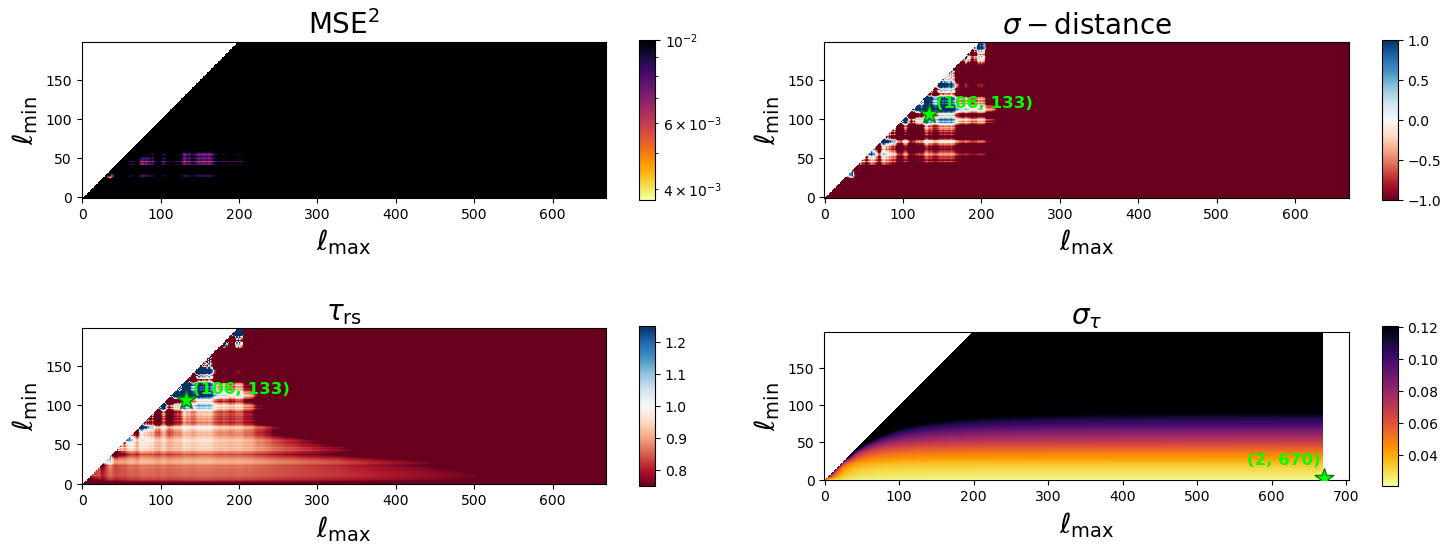

0

In [76]:
plot_tau_grid(tauB_grid, sigmaB_grid, lmin_arrB, lmax_arrB)

### Noisy case

In [22]:
def tau_gridN(map0, map1, map_beam0, map_beam1, map_cmb,  sigmaN0, sigmaN1, lmin_arr, lmax_arr, N):  
    '''
    mean and sigma of tau distribution of E[tau] obtained from N noise realizations, for all multipole ranges
    Args: 
    - map0, map1: maps at 2 frequencies --> to compute difference map (DATA)
    - map_beam0, map_beam1: beam maps --> use to deconvolve
    - map_cmb: original CMB realization to use as template
    - lmin_arr, lmax_arr: 1D arrays of multipole ranges to analyze
    - N=number of noise realizations
    Return: tau_grid, sigma_grid: 2D arrays with mean, sigma of distriburion of matched filter results for N noise realizations, for every (lmin,lmax)  
    '''

    LMAX=lmax_arr[-1]

    #map alms
    alm0=hp.map2alm(map0, lmax=LMAX, use_pixel_weights=True)
 
    alm1=hp.map2alm(map1, lmax=LMAX, use_pixel_weights=True)
    alm_template_cmb=hp.map2alm(map_cmb, lmax=LMAX, use_pixel_weights=True)  
 
    #beam Cls 
    Cls_beam0=hp.anafast(map_beam0, lmax=LMAX, use_pixel_weights=True)*4*np.pi  # symmetrized beams, up to lmax
    Cls_beam1=hp.anafast(map_beam1, lmax=LMAX, use_pixel_weights=True)*4*np.pi 
    bl0_inv=1/np.sqrt(Cls_beam0)
    bl1_inv=1/np.sqrt(Cls_beam1)

    check_beam0=np.all(np.abs(Cls_beam0[:3] - 1) < 1e-2) #CHECK: beam norm
    check_beam1=np.all(np.abs(Cls_beam1[:3] - 1) < 1e-2)   
    if not check_beam0 or not check_beam1:
        print("ERROR: beam normalizations is off (first multiples differ > 1e-2 from 1")

    lmax_alm = hp.Alm.getlmax(len(alm0))  #CHECK: if alms and bl have the same lmax
    lmax_bl  = len(bl0_inv) - 1  # bl is indexed 0..lmax
    assert lmax_alm == lmax_bl, f"ERROR: lmax mismatch: alms have lmax={lmax_alm}, bl has lmax={lmax_bl}"

    #noise levels 
    nside=hp.get_nside(map0)
    pixArea_rad=hp.nside2pixarea(nside, degrees=False)
    sigmaN0_alms=np.sqrt(pixArea_rad)*sigmaN0
    sigmaN1_alms=np.sqrt(pixArea_rad)*sigmaN1

    Cl_noise0=pixArea_rad*sigmaN0**2/Cls_beam0 #th. noise Cls, needed for subtraction
    Cl_noise1= -pixArea_rad*sigmaN1**2/Cls_beam1
    Clnoise_list=[Cl_noise0, Cl_noise1, 0.]  #noise Cls for subtraction (only for cross Cls with template 0 or 1)

    #set seed to generate independent noise realizations --> same for all l-ranges
    MS0 = np.random.SeedSequence(88)   # master seed 
    MS1 = np.random.SeedSequence(42)   
    s0 = MS0.spawn(N)  #sequence of N seeds (same when master seed is the same)
    s1 = MS1.spawn(N)  

   #LOOP OVER NOISE REALIZATIONS 
    nom_l_all = np.zeros((N, LMAX+1)) #arrays to store results for all noise realizations: [i][j]-->i=noise realizations, j=ell 
    denom_l_all = np.zeros((N, LMAX+1)) #each row is a different noise realization
    for ii in range(N):
        almN0=ftau.get_noise_alm(sigmaN0_alms, LMAX, seed=s0[ii]) #generate noise
        almN1=ftau.get_noise_alm(sigmaN1_alms, LMAX, seed=s1[ii])
 
        alm0_n=alm0+almN0  #add noise to maps
        alm1_n=alm1+almN1

        alm0_n_dec=hp.almxfl(alm0_n, bl0_inv)  #deconvolve 
        alm1_n_dec=hp.almxfl(alm1_n, bl1_inv)   
        alm_data=alm0_n_dec-alm1_n_dec #get data map
        
        #templates
        alm_template=alm0_n_dec
        templates_list=[alm0_n_dec, alm1_n_dec, alm_template_cmb]  

        #compute Cls: dim=LMAX (automatic)
        Cl_cov=hp.alm2cl(alm_data)   #Cls of covariance = Cls of data (APPROX.)

        Cl_crossT=hp.alm2cl(alm_data, alm_template)-Cl_noise0   #cross Cls --> NOM
        Cl_T=hp.alm2cl(alm_template)  #template Cls --> DENOM

        #matche filter quantities
        l=np.arange(0, LMAX+1)
        nom_l_all[ii, :]=(2*l+1)*Cl_crossT/Cl_cov  #nom_l_all[ii, :] corresponds to the i-th noise realization
        denom_l_all[ii, :]=(2*l+1)*Cl_T/Cl_cov

    
    #MATCHED FILTER - LOOP OVER ELL
    tau_mean_grid = np.full((len(lmin_arr), len(lmax_arr)), np.nan)  #define the grid to store tau mean and its error
    tau_sigma_grid = np.full((len(lmin_arr), len(lmax_arr)), np.nan)  
    for i, lmin in enumerate(lmin_arr):  #i=0,1,2,... lmin=lmin_arr[0], lmin_arr[1], ...
        for j, lmax in enumerate(lmax_arr):            
            if lmax >= lmin:  # only valid combinations
                nom=np.sum(nom_l_all[:, lmin:lmax+1], axis=1)
                denom=np.sum(denom_l_all[:, lmin:lmax+1], axis=1)
                Etau=nom/denom*1e3   
                tau_mean_grid[i,j]=np.mean(Etau)
                tau_sigma_grid[i,j]=np.std(Etau)
    return tau_mean_grid, tau_sigma_grid


In [23]:
N_realizations=100 #100-->5s // 500-->30s //
lmin=2
lmax=670
lmin_cap=200
lmin_arr=np.arange(lmin, lmin_cap+1)
lmax_arr=np.arange(lmin, lmax+1)
tauN_grid, sigmaN_grid=tau_gridN(map0symm, map1symm, beam0, beam1, map_cmb, sigmaN0, sigmaN1, lmin_arr, lmax_arr, N_realizations)

In [24]:
tauBN_grid, sigmaBN_grid=tau_gridN(map0, map1, beam0, beam1, map_cmb, sigmaN0, sigmaN1, lmin_arr, lmax_arr, N_realizations)

In [25]:
## best values according to min. MSE
bestrangeN = bestrange_MSE(tauN_grid, sigmaN_grid, lmin_arr , lmax_arr)
bestrangeBN = bestrange_MSE(tauBN_grid, sigmaBN_grid, lmin_arr , lmax_arr)

lmin_bestN=bestrangeN['lmin'][0]
lmax_bestN=bestrangeN['lmax'][0]
lmin_bestBN=bestrangeBN['lmin'][0]
lmax_bestBN=bestrangeBN['lmax'][0]

print('NOISE:')
for i in range(len(bestrangeN['tau'])):
    print(f"{i+1:2d}) lmin={bestrangeN['lmin'][i]}, lmax={bestrangeN['lmax'][i]} ({bestrangeN['lmax'][i] - bestrangeN['lmin'][i] + 1} multipoles) "
          f"τ={bestrangeN['tau'][i]:.6f}, σ={bestrangeN['sigma'][i]:.6f}, σ_dist={(bestrangeN['tau'][i]-1.)/bestrangeN['sigma'][i]:.6f}, MSqE={bestrangeN['MSqE'][i]:.6f}")
print('\nNOISE + BEAM:')
for i in range(len(bestrangeBN['tau'])):
    print(f"{i+1:2d}) lmin={bestrangeBN['lmin'][i]}, lmax={bestrangeBN['lmax'][i]} ({bestrangeBN['lmax'][i] - bestrangeBN['lmin'][i] + 1} multipoles) "
          f"τ={bestrangeBN['tau'][i]:.6f}, σ={bestrangeBN['sigma'][i]:.6f}, σ_dist={(bestrangeBN['tau'][i]-1.)/bestrangeBN['sigma'][i]:.6f}, MSqE={bestrangeBN['MSqE'][i]:.6f}")
    


NOISE:
 1) lmin=6, lmax=305 (300 multipoles) τ=0.907526, σ=0.269602, σ_dist=-0.343004, MSqE=0.081237
 2) lmin=6, lmax=285 (280 multipoles) τ=0.915870, σ=0.272436, σ_dist=-0.308808, MSqE=0.081299
 3) lmin=6, lmax=431 (426 multipoles) τ=0.901341, σ=0.267518, σ_dist=-0.368793, MSqE=0.081300
 4) lmin=6, lmax=429 (424 multipoles) τ=0.901320, σ=0.267556, σ_dist=-0.368819, MSqE=0.081324
 5) lmin=6, lmax=287 (282 multipoles) τ=0.915026, σ=0.272247, σ_dist=-0.312120, MSqE=0.081339

NOISE + BEAM:
 1) lmin=2, lmax=244 (243 multipoles) τ=1.039609, σ=0.258006, σ_dist=0.153518, MSqE=0.068136
 2) lmin=2, lmax=245 (244 multipoles) τ=1.038847, σ=0.258568, σ_dist=0.150240, MSqE=0.068367
 3) lmin=2, lmax=243 (242 multipoles) τ=1.042685, σ=0.258014, σ_dist=0.165438, MSqE=0.068393
 4) lmin=2, lmax=246 (245 multipoles) τ=1.042367, σ=0.258531, σ_dist=0.163877, MSqE=0.068633
 5) lmin=2, lmax=239 (238 multipoles) τ=1.048173, σ=0.258283, σ_dist=0.186514, MSqE=0.069031


31.979233781089178
MSE best: 	lmin=6, lmax=305 	τ=(0.907526±0.269602) 	MSE=0.081237 	σ-dist=-0.343004
σ-dist best: 	lmin=147, lmax=235 	τ=(1.000000±0.503620) 	MSE=0.253633 	σ-dist=0.000001
tau best: 	lmin=104, lmax=261 	τ=(1.000000±0.386206) 	MSE=0.149155 	σ-dist=0.000001
sigma best: 	lmin=2, lmax=650 	τ=(0.767369±0.239619) 	MSE=0.111534 	σ-dist=-0.970834


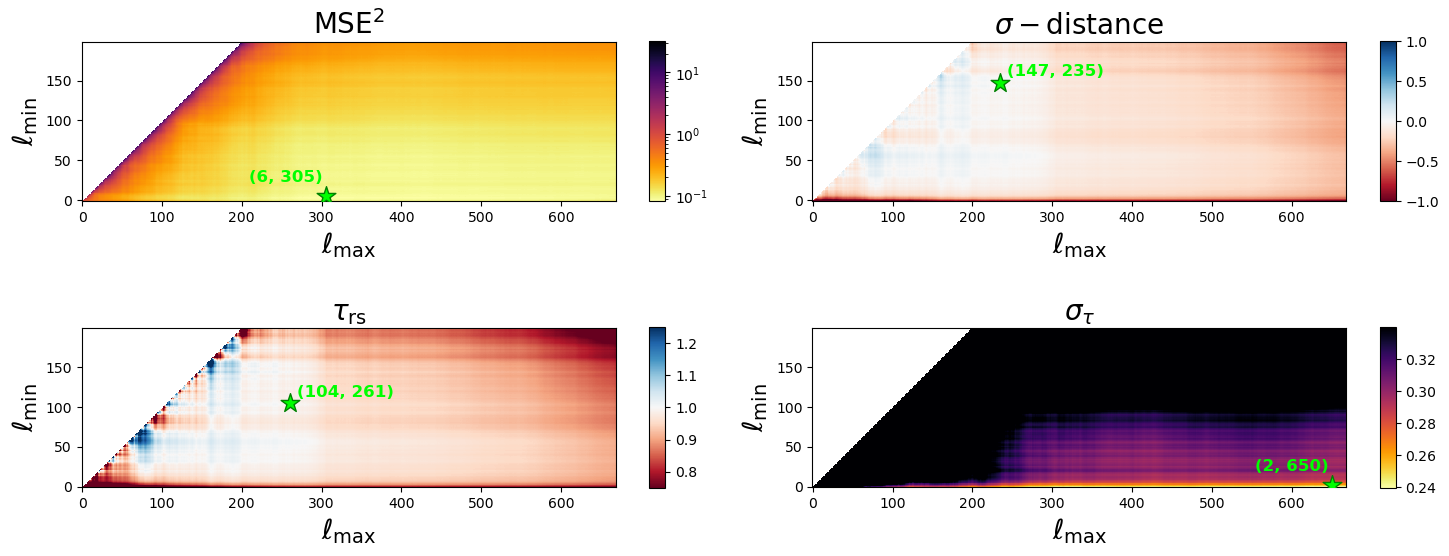

0

In [26]:
plot_tau_grid(tauN_grid, sigmaN_grid, lmin_arr, lmax_arr)

69.70524229972452
MSE best: 	lmin=2, lmax=244 	τ=(1.039609±0.258006) 	MSE=0.068136 	σ-dist=0.153518
σ-dist best: 	lmin=51, lmax=111 	τ=(1.000010±0.550089) 	MSE=0.302598 	σ-dist=0.000017
tau best: 	lmin=51, lmax=111 	τ=(1.000010±0.550089) 	MSE=0.302598 	σ-dist=0.000017
sigma best: 	lmin=2, lmax=308 	τ=(1.257289±0.251152) 	MSE=0.129275 	σ-dist=1.024438


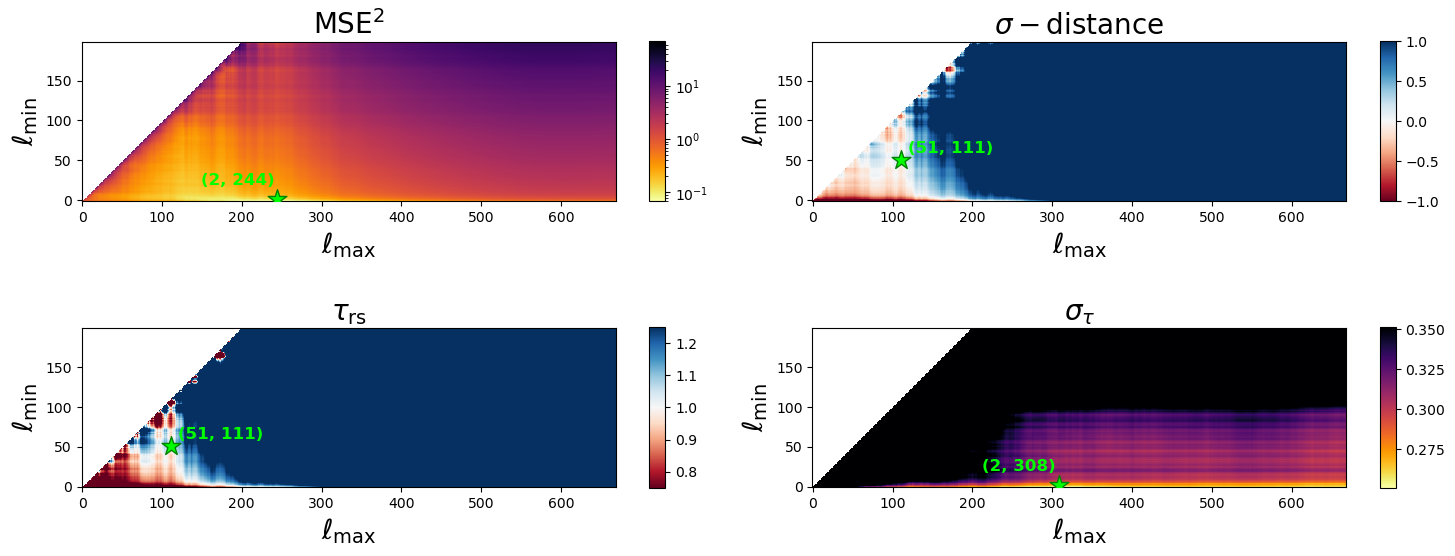

0

In [27]:
plot_tau_grid(tauBN_grid, sigmaBN_grid, lmin_arr, lmax_arr)

### Multiple templates

In [50]:
def tau_grid3_noiseless(map0, map1, map_beam0, map_beam1, map_cmb, lmin_arr, lmax_arr):  
    '''
    tau,sigma from matched filter for different ell-ranges
    Args: 
    - map0, map1: maps at 2 frequencies --> to compute difference map (DATA)
    - map_beam0, map_beam1: beam maps --> use to deconvolve
    - map_cmb: original CMB realization to use as template
    - lmin_arr, lmax_arr: 1D arrays of multipole ranges to analyze
    Return: tau_grid, sigma_grid: 2D arrays with matched filter results for every (lmin,lmax)
    '''

    LMAX=lmax_arr[-1]
  
    #map alms
    alm0=hp.map2alm(map0, lmax=LMAX, use_pixel_weights=True) 
    alm1=hp.map2alm(map1, lmax=LMAX, use_pixel_weights=True)
    alm_template_cmb=hp.map2alm(map_cmb, lmax=LMAX, use_pixel_weights=True)  
 
    #beam Cls 
    Cls_beam0=hp.anafast(map_beam0, lmax=LMAX, use_pixel_weights=True)*4*np.pi  # symmetrized beams, up to lmax
    Cls_beam1=hp.anafast(map_beam1, lmax=LMAX, use_pixel_weights=True)*4*np.pi 
    bl0_inv=1/np.sqrt(Cls_beam0)
    bl1_inv=1/np.sqrt(Cls_beam1)

    check_beam0=np.all(np.abs(Cls_beam0[:3] - 1) < 1e-2) #CHECK: beam norm
    check_beam1=np.all(np.abs(Cls_beam1[:3] - 1) < 1e-2)   
    if not check_beam0 or not check_beam1:
        print("ERROR: beam normalizations is off (first multiples differ > 1e-2 from 1")

    lmax_alm = hp.Alm.getlmax(len(alm0))  #CHECK: if alms and bl have the same lmax
    lmax_bl  = len(bl0_inv) - 1  # bl is indexed 0..lmax
    assert lmax_alm == lmax_bl, f"ERROR: lmax mismatch: alms have lmax={lmax_alm}, bl has lmax={lmax_bl}"

    alm0_dec=hp.almxfl(alm0, bl0_inv)  #deconvolve 
    alm1_dec=hp.almxfl(alm1, bl1_inv)   
    alm_data=alm0_dec-alm1_dec #get data map

    #templates
    alm_templates=[alm0_dec, alm1_dec, alm_template_cmb]  

    #compute Cls: dim=LMAX (automatic)
    Cl_cov=hp.alm2cl(alm_data)   #Cls of covariance = Cls of data (APPROX.)

    #matche filter quantities
    l=np.arange(0, LMAX+1)
    w=(2*l+1)/Cl_cov
    nom_l= np.zeros((3, LMAX+1)) #arrays to store results for all noise realizations: [i][j]-->i=noise realizations, j=ell 
    denom_l = np.zeros((3, LMAX+1)) 
    for k in range(3):
        Cl_crossT=hp.alm2cl(alm_data, alm_templates[k])  #cross Cls --> NOM
        Cl_T=hp.alm2cl(alm_templates[k])  #template Cls --> DENOM

        nom_l[k,:]=w*Cl_crossT  #nom_l_all[ii, :] corresponds to the i-th noise realization
        denom_l[k,:]=w*Cl_T

    #MATCHED FILTER - LOOP OVER ELL
    tau_grid = np.full((3, len(lmin_arr), len(lmax_arr)), np.nan)  # define the grid to store tau values
    sigma_grid = np.full((3, len(lmin_arr), len(lmax_arr)), np.nan)  
    for i, lmin in enumerate(lmin_arr):
        for j, lmax in enumerate(lmax_arr):            
            if lmax >= lmin:  # only valid combinations
                nom = np.sum(nom_l[:, lmin:lmax+1], axis=1)      # shape (3,)
                denom = np.sum(denom_l[:, lmin:lmax+1], axis=1)  # shape (3,)
                tau_grid[:, i, j] = nom / denom * 1e3
                sigma_grid[:, i, j] = np.sqrt(1 / denom) * 1e3            

    return tau_grid, sigma_grid


In [ ]:
def tau_gridN3(map0, map1, map_beam0, map_beam1, map_cmb,  sigmaN0, sigmaN1, lmin_arr, lmax_arr, N):  
    '''
    mean and sigma of tau distribution of E[tau] obtained from N noise realizations, for all multipole ranges
    Args: 
    - map0, map1: maps at 2 frequencies --> to compute difference map (DATA)
    - map_beam0, map_beam1: beam maps --> use to deconvolve
    - map_cmb: original CMB realization to use as template
    - lmin_arr, lmax_arr: 1D arrays of multipole ranges to analyze
    - N=number of noise realizations
    Return: tau_grid, sigma_grid: 2D arrays with mean, sigma of distriburion of matched filter results for N noise realizations, for every (lmin,lmax)  
    '''

    LMAX=lmax_arr[-1]

    #map alms
    alm0=hp.map2alm(map0, lmax=LMAX, use_pixel_weights=True)
 
    alm1=hp.map2alm(map1, lmax=LMAX, use_pixel_weights=True)
    alm_template_cmb=hp.map2alm(map_cmb, lmax=LMAX, use_pixel_weights=True)  
 
    #beam Cls 
    Cls_beam0=hp.anafast(map_beam0, lmax=LMAX, use_pixel_weights=True)*4*np.pi  # symmetrized beams, up to lmax
    Cls_beam1=hp.anafast(map_beam1, lmax=LMAX, use_pixel_weights=True)*4*np.pi 
    bl0_inv=1/np.sqrt(Cls_beam0)
    bl1_inv=1/np.sqrt(Cls_beam1)

    check_beam0=np.all(np.abs(Cls_beam0[:3] - 1) < 1e-2) #CHECK: beam norm
    check_beam1=np.all(np.abs(Cls_beam1[:3] - 1) < 1e-2)   
    if not check_beam0 or not check_beam1:
        print("ERROR: beam normalizations is off (first multiples differ > 1e-2 from 1")

    lmax_alm = hp.Alm.getlmax(len(alm0))  #CHECK: if alms and bl have the same lmax
    lmax_bl  = len(bl0_inv) - 1  # bl is indexed 0..lmax
    assert lmax_alm == lmax_bl, f"ERROR: lmax mismatch: alms have lmax={lmax_alm}, bl has lmax={lmax_bl}"

    #noise levels 
    nside=hp.get_nside(map0)
    pixArea_rad=hp.nside2pixarea(nside, degrees=False)
    sigmaN0_alms=np.sqrt(pixArea_rad)*sigmaN0
    sigmaN1_alms=np.sqrt(pixArea_rad)*sigmaN1

    Cl_noise0=pixArea_rad*sigmaN0**2/Cls_beam0 #th. noise Cls, needed for subtraction
    Cl_noise1= -pixArea_rad*sigmaN1**2/Cls_beam1
    Clnoise_list=[Cl_noise0, Cl_noise1, 0.]  #noise Cls for subtraction (only for cross Cls with template 0 or 1)

    #set seed to generate independent noise realizations --> same for all l-ranges
    MS0 = np.random.SeedSequence(88)   # master seed 
    MS1 = np.random.SeedSequence(42)   
    s0 = MS0.spawn(N)  #sequence of N seeds (same when master seed is the same)
    s1 = MS1.spawn(N)  

   #LOOP OVER NOISE REALIZATIONS 
    nom_l_all = np.zeros((3,N, LMAX+1)) #arrays to store results for all noise realizations: [i][j]-->i=noise realizations, j=ell 
    denom_l_all = np.zeros((3,N, LMAX+1)) #each row is a different noise realization
    for ii in range(N):
        almN0=ftau.get_noise_alm(sigmaN0_alms, LMAX, seed=s0[ii]) #generate noise
        almN1=ftau.get_noise_alm(sigmaN1_alms, LMAX, seed=s1[ii])
 
        alm0_n=alm0+almN0  #add noise to maps
        alm1_n=alm1+almN1

        alm0_n_dec=hp.almxfl(alm0_n, bl0_inv)  #deconvolve 
        alm1_n_dec=hp.almxfl(alm1_n, bl1_inv)   
        alm_data=alm0_n_dec-alm1_n_dec #get data map
        
        #templates
        alm_templates=[alm0_n_dec, alm1_n_dec, alm_template_cmb]  

        #compute Cls: dim=LMAX (automatic)
        Cl_cov=hp.alm2cl(alm_data)   #Cls of covariance = Cls of data (APPROX.)

        #matcheD filter quantities
        l=np.arange(0, LMAX+1)
        w=(2*l+1)/Cl_cov
        for k in range(3):
            Cl_crossT=hp.alm2cl(alm_data, alm_templates[k])-Clnoise_list[k]   #cross Cls --> NOM
            Cl_T=hp.alm2cl(alm_templates[k])  #template Cls --> DENOM

            nom_l_all[k, ii, :]=w*Cl_crossT  #nom_l_all[ii, :] corresponds to the i-th noise realization
            denom_l_all[k, ii, :]=w*Cl_T

    
    #MATCHED FILTER - LOOP OVER ELL
    tau_mean_grid = np.full((3, len(lmin_arr), len(lmax_arr)), np.nan)  #define the grid to store tau mean and its error
    tau_sigma_grid = np.full((3, len(lmin_arr), len(lmax_arr)), np.nan) 
    for k in range(3): 
        for i, lmin in enumerate(lmin_arr):  #i=0,1,2,... lmin=lmin_arr[0], lmin_arr[1], ...
            for j, lmax in enumerate(lmax_arr):            
                if lmax >= lmin:  # only valid combinations
                    nom=np.sum(nom_l_all[k, :, lmin:lmax+1], axis=1)  #sum over ell --> out: array of tau, sigma results for N noise realizations
                    denom=np.sum(denom_l_all[k, :, lmin:lmax+1], axis=1)
                    Etau=nom/denom*1e3  #array of len=N
                    tau_mean_grid[k,i,j]=np.mean(Etau)
                    tau_sigma_grid[k,i,j]=np.std(Etau)
    return tau_mean_grid, tau_sigma_grid


In [29]:
def plot_tau_grid3(tau_grid3, sigma_grid3, lmin_arr, lmax_arr):
    
    bias_grid3=tau_grid3-1.
    sigmadist_grid3=bias_grid3/sigma_grid3
    MSqE_grid3=sigma_grid3**2+bias_grid3**2 
    
    #plot options 
    cbar_height=0.4

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    axes = axes.ravel() 

    valmin=np.zeros(3)+0.07
    valmax=np.zeros(3)+0.2
    #alternative: take min of all values 
    '''
    for k in range(3): 
        min=np.nanmin(MSqE_grid3[k])
        max=np.nanmax(MSqE_grid3[k])
        valmin[k]=min
        valmax[k]=max
        valmax[k]=min+0.025*(max-min)
    '''

    # TEMPLATE 0 
    axes[0].set_title('Template: 30GHz map', fontsize=15)
    im0 = axes[0].imshow(MSqE_grid3[0], origin='lower', cmap='inferno_r', vmin=np.nanmin(MSqE_grid3[0]), vmax=valmax[0])  #norm=LogNorm(vmin=valmin[0], vmax=valmax[0]) )  #norm=LogNorm(vmin=np.nanmin(MSqE_grid3[0]), vmax=vmax)
    plt.colorbar(im0, ax=axes[0], shrink=cbar_height, aspect=10)
    lmin0, lmax0, idx0 =bestrange_general(MSqE_grid3[0], lmin_arr, lmax_arr, bestvalue=0.)
    axes[0].scatter(lmax0, lmin0, marker='*', s=200, c='lime', edgecolors='green', zorder=10) #SELECTED best lmin,lmax
    axes[0].annotate( f'({lmin0}, {lmax0})', xy=(lmax0, lmin0), xytext=(-55, 10), textcoords='offset points', color='lime', fontsize=12 , fontweight='bold')
    print('\nTemplate: 30GHz map')
    bestrange0=bestrange_MSE(tau_grid3[0], sigma_grid3[0], lmin_arr, lmax_arr, tau_in=1.0, printopt=True)

        # TEMPLATE 1
    axes[1].set_title('Template: 70GHz map', fontsize=15)
    im1 = axes[1].imshow(MSqE_grid3[1], origin='lower', cmap='inferno_r', vmin=np.nanmin(MSqE_grid3[1]), vmax=valmax[1] )  #norm=LogNorm(vmin=valmin[1], vmax=valmax[1]) ), vmax=vmax)
    plt.colorbar(im1, ax=axes[1], shrink=cbar_height, aspect=10)
    lmin1, lmax1, idx1 =bestrange_general(MSqE_grid3[1], lmin_arr, lmax_arr, bestvalue=0.)
    axes[1].scatter(lmax1, lmin1, marker='*', s=200, c='lime', edgecolors='green', zorder=10) #SELECTED best lmin,lmax
    axes[1].annotate( f'({lmin1}, {lmax1})', xy=(lmax1, lmin1), xytext=(-55, 10), textcoords='offset points', color='lime', fontsize=12 , fontweight='bold')
    print('\nTemplate: 70GHz map')
    bestrange1=bestrange_MSE(tau_grid3[1], sigma_grid3[1], lmin_arr, lmax_arr, tau_in=1.0, printopt=True)

    # TEMPLATE 2
    axes[2].set_title('Template: clean CMB map', fontsize=15)
    im2 = axes[2].imshow(MSqE_grid3[2], origin='lower', cmap='inferno_r', vmin=np.nanmin(MSqE_grid3[2]), vmax=valmax[2] )  #norm=LogNorm(vmin=valmin[2], vmax=valmax[2]) ), vmax=vmax)
    plt.colorbar(im2, ax=axes[2], shrink=cbar_height, aspect=10)
    lmin2, lmax2, idx2 =bestrange_general(MSqE_grid3[2], lmin_arr, lmax_arr, bestvalue=0.)
    axes[2].scatter(lmax2, lmin2, marker='*', s=200, c='lime', edgecolors='green', zorder=10) #SELECTED best lmin,lmax
    axes[2].annotate( f'({lmin2}, {lmax2})', xy=(lmax2, lmin2), xytext=(-55, 10), textcoords='offset points', color='lime', fontsize=12 , fontweight='bold')
    print('\nTemplate: clean CMB map')
    bestrange2=bestrange_MSE(tau_grid3[2], sigma_grid3[2], lmin_arr, lmax_arr, tau_in=1.0, printopt=True)



    for i in range(3): 
        axes[i].set_xlabel(r'$\ell_{\rm max}$', fontsize=20)
        axes[i].set_ylabel(r'$\ell_{\rm min}$', fontsize=20)
        #axes[i].scatter(tau_best['lmax'][0], tau_best['lmin'][0], marker='*', s=100, c='lime', edgecolors='red', zorder=10) #SELECTED best lmin,lmax 

    plt.tight_layout()
    plt.show()



    return 0

In [82]:
LMIN=2
LMAX=700
lmin_cap=200
lmin_arrB=np.arange(LMIN, lmin_cap+1)
lmax_arrB=np.arange(LMIN, LMAX+1)
tauB_grid3, sigmaB_grid3 = tau_grid3_noiseless(map0, map1, beam0, beam1, map_cmb, lmin_arrB, lmax_arrB)

In [30]:
N_realizations=100 #100-->5s // 500-->30s //
lmin=2
lmax=670
lmin_cap=200
lmin_arr=np.arange(lmin, lmin_cap+1)
lmax_arr=np.arange(lmin, lmax+1)
tauN_grid3, sigmaN_grid3=tau_gridN3(map0symm, map1symm, beam0, beam1, map_cmb, sigmaN0, sigmaN1, lmin_arr, lmax_arr, N_realizations)

In [31]:
tauBN_grid3, sigmaBN_grid3=tau_gridN3(map0, map1, beam0, beam1, map_cmb, sigmaN0, sigmaN1, lmin_arr, lmax_arr, N_realizations)


Template: 30GHz map
lmin=7, lmax=700	 τ=(0.997955±0.026148)	MSqE=0.000688	σ_dist=-0.078208

Template: 70GHz map
lmin=27, lmax=38	 τ=(0.996517±0.061119)	MSqE=0.003748	σ_dist=-0.056985

Template: clean CMB map
lmin=27, lmax=38	 τ=(0.995431±0.061064)	MSqE=0.003750	σ_dist=-0.074827


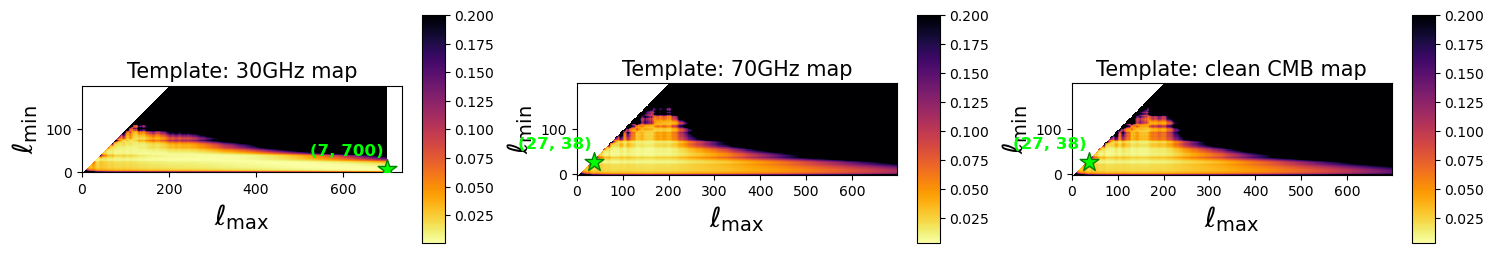

0

In [64]:
plot_tau_grid3(tauB_grid3, sigmaB_grid3, lmin_arrB, lmax_arrB)


Template: 30GHz map
lmin=6, lmax=305	 τ=(0.907526±0.269602)	MSqE=0.081237	σ_dist=-0.343004

Template: 70GHz map
lmin=6, lmax=589	 τ=(0.956535±0.263126)	MSqE=0.071125	σ_dist=-0.165185

Template: clean CMB map
lmin=6, lmax=589	 τ=(0.934438±0.266592)	MSqE=0.075370	σ_dist=-0.245926


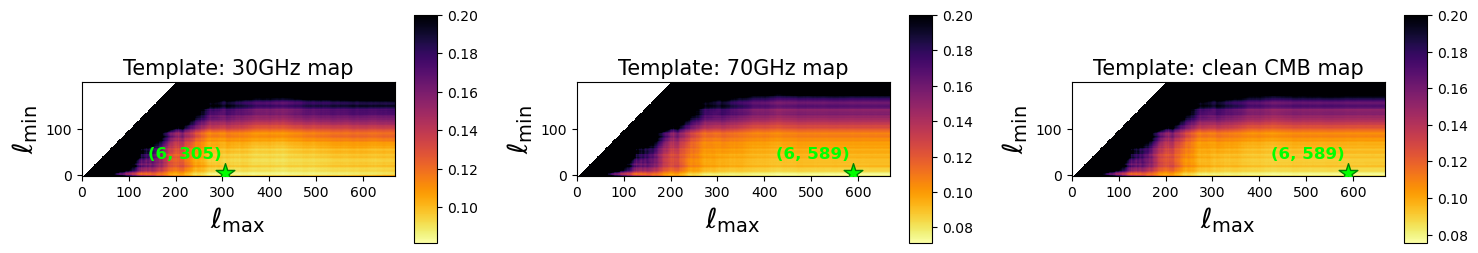

0

In [32]:
plot_tau_grid3(tauN_grid3, sigmaN_grid3, lmin_arr, lmax_arr)


Template: 30GHz map
lmin=2, lmax=244	 τ=(1.039609±0.258006)	MSqE=0.068136	σ_dist=0.153518

Template: 70GHz map
lmin=5, lmax=164	 τ=(0.905050±0.320384)	MSqE=0.111661	σ_dist=-0.296365

Template: clean CMB map
lmin=6, lmax=164	 τ=(0.880128±0.324752)	MSqE=0.119833	σ_dist=-0.369118


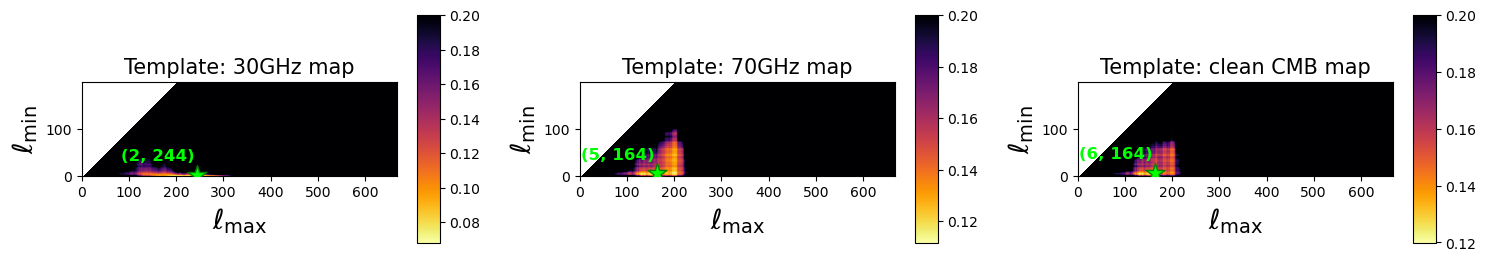

0

In [33]:
plot_tau_grid3(tauBN_grid3, sigmaBN_grid3, lmin_arr, lmax_arr)

In [83]:
## GET all optimal ranges based on MSE, for all templates
lmin_bestB, lmax_bestB, tauB_best, sigmaB_best, MSE_bestB, sigmadistB_best = np.zeros(3, int), np.zeros(3, int), np.zeros(3), np.zeros(3), np.zeros(3), np.zeros(3)
lmin_bestN, lmax_bestN, tauN_best, sigmaN_best, MSE_bestN, sigmadistN_best = np.zeros(3, int), np.zeros(3, int), np.zeros(3), np.zeros(3), np.zeros(3), np.zeros(3)
lmin_bestBN, lmax_bestBN, tauBN_best, sigmaBN_best, MSE_bestBN, sigmadistBN_best= np.zeros(3, int), np.zeros(3, int), np.zeros(3), np.zeros(3), np.zeros(3), np.zeros(3)

for t in range(3): #loop over templates
    #bestrangeB = bestrange_MSE(tauB_grid, sigmaB_grid, lmin_arrB, lmax_arrB, tau_in=1.0)
    bestrangeB= bestrange_MSE(tauB_grid3[t], sigmaB_grid3[t], lmin_arrB, lmax_arrB, tau_in=1.0)
    bestrangeN = bestrange_MSE(tauN_grid3[t], sigmaN_grid3[t], lmin_arr, lmax_arr, tau_in=1.0)
    bestrangeBN = bestrange_MSE(tauBN_grid3[t], sigmaBN_grid3[t], lmin_arr, lmax_arr, tau_in=1.0)

    lmin_bestB[t]=bestrangeB['lmin'][0]
    lmax_bestB[t]=bestrangeB['lmax'][0]
    tauB_best[t]=bestrangeB['tau'][0]
    sigmaB_best[t]=bestrangeB['sigma'][0]
    MSE_bestB[t]=bestrangeB['MSqE'][0]
    sigmadistB_best[t]=(tauB_best[t]-1.)/sigmaB_best[t]

    lmin_bestN[t]=bestrangeN['lmin'][0]
    lmax_bestN[t]=bestrangeN['lmax'][0]
    tauN_best[t]=bestrangeN['tau'][0]
    sigmaN_best[t]=bestrangeN['sigma'][0]
    MSE_bestN[t]=bestrangeN['MSqE'][0]
    sigmadistN_best[t]=(tauN_best[t]-1.)/sigmaN_best[t]

    lmin_bestBN[t]=bestrangeBN['lmin'][0]
    lmax_bestBN[t]=bestrangeBN['lmax'][0]
    tauBN_best[t]=bestrangeBN['tau'][0]
    sigmaBN_best[t]=bestrangeBN['sigma'][0]
    MSE_bestBN[t]=bestrangeBN['MSqE'][0]
    sigmadistBN_best[t]=(tauBN_best[t]-1.)/sigmaBN_best[t]

In [144]:
TEMPLATES = ["30GHz", "70GHz", "CMB"]

# --- Case B ---
df_B = pd.DataFrame({
    "template":  TEMPLATES, 
    "lmin":      lmin_bestB,
    "lmax":      lmax_bestB,
    "tau":       tauB_best,
    "sigma":     sigmaB_best,
    "MSE":       MSE_bestB,
    "sigmadist": sigmadistB_best,
    "significance": 1/sigmaB_best
    
}).set_index("template")

# --- Case N ---
df_N = pd.DataFrame({
    "template":  TEMPLATES,
    "lmin":      lmin_bestN,
    "lmax":      lmax_bestN,
    "tau":       tauN_best,
    "sigma":     sigmaN_best,
    "MSE":       MSE_bestN,
    "sigmadist": sigmadistN_best,
    "significance": 1/sigmaN_best
}).set_index("template")

# --- Case BN ---
df_BN = pd.DataFrame({
    "template":  TEMPLATES,
    "lmin":      lmin_bestBN,
    "lmax":      lmax_bestBN,
    "tau":       tauBN_best,
    "sigma":     sigmaBN_best,
    "MSE":       MSE_bestBN,
    "sigmadist": sigmadistBN_best,
    "significance": 1/sigmaBN_best
}).set_index("template")

# --- Display ---
print("Case: BEAM");  display(df_B)
print("Case: NOISE");  display(df_N)
print("Case: BEAM + NOISE"); display(df_BN)

Case: BEAM


,lmin,lmax,tau,sigma,MSE,sigmadist,significance
template,,,,,,,
30GHz,7,700,0.997955,0.026148,0.000688,-0.078208,38.244389
70GHz,27,38,0.996517,0.061119,0.003748,-0.056985,16.361601
CMB,27,38,0.995431,0.061064,0.003750,-0.074827,16.376365


Case: NOISE


,lmin,lmax,tau,sigma,MSE,sigmadist,significance
template,,,,,,,
30GHz,6,305,0.907526,0.269602,0.081237,-0.343004,3.709171
70GHz,6,589,0.956535,0.263126,0.071125,-0.165185,3.800454
CMB,6,589,0.934438,0.266592,0.075370,-0.245926,3.751050


Case: BEAM + NOISE


,lmin,lmax,tau,sigma,MSE,sigmadist,significance
template,,,,,,,
30GHz,2,244,1.039609,0.258006,0.068136,0.153518,3.875883
70GHz,5,164,0.905050,0.320384,0.111661,-0.296365,3.121255
CMB,6,164,0.880128,0.324752,0.119833,-0.369118,3.079278


In [146]:
latex = df_BN.to_latex(
    index=False,
    float_format="%.3f",
    caption="Results",
    label="tab:results"
)

print(latex)

\begin{table}
\caption{Results}
\label{tab:results}
\begin{tabular}{rrrrrrr}
\toprule
lmin & lmax & tau & sigma & MSE & sigmadist & significance \\
\midrule
2 & 244 & 1.040 & 0.258 & 0.068 & 0.154 & 3.876 \\
5 & 164 & 0.905 & 0.320 & 0.112 & -0.296 & 3.121 \\
6 & 164 & 0.880 & 0.325 & 0.120 & -0.369 & 3.079 \\
\bottomrule
\end{tabular}
\end{table}



N =  100 realizations E[τ] results
╒════════════╤═══════════════════════╤═══════════════════════╤══════════════════════╕
│ Template   │ E[τ]mean Noise only   │ Noise+Beam: mean(τ)   │ Beam only: mean(τ)   │
╞════════════╪═══════════════════════╪═══════════════════════╪══════════════════════╡
│ 30GHz      │ (0.908 ± 0.270)×10⁻³  │ (1.040 ± 0.258)×10⁻³  │ (0.998 ± 0.026)×10⁻³ │
├────────────┼───────────────────────┼───────────────────────┼──────────────────────┤
│ 70GHz      │ (0.957 ± 0.263)×10⁻³  │ (0.905 ± 0.320)×10⁻³  │ (0.997 ± 0.061)×10⁻³ │
├────────────┼───────────────────────┼───────────────────────┼──────────────────────┤
│ CMB        │ (0.934 ± 0.267)×10⁻³  │ (0.880 ± 0.325)×10⁻³  │ (0.995 ± 0.061)×10⁻³ │
╘════════════╧═══════════════════════╧═══════════════════════╧══════════════════════╛
[0.  0.2 0.4]


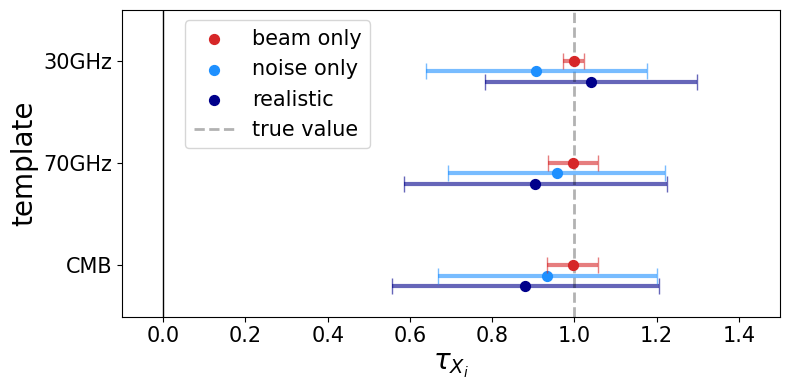

In [135]:
### PLOT CENTRAL VALUES
templates=['30GHz','70GHz','CMB']
result_B = [f"({v:.3f} ± {e:.3f})×10⁻³" for v, e in zip(tauB_best, sigmaB_best)]
result_N = [f"({v:.3f} ± {e:.3f})×10⁻³" for v, e in zip(tauN_best, sigmaN_best)]
result_BN = [f"({v:.3f} ± {e:.3f})×10⁻³" for v, e in zip(tauBN_best, sigmaBN_best)]

print('N = ', N_realizations, 'realizations E[τ] results' )
print(tabulate({ "Template": templates, "E[τ]mean Noise only": result_N, "Noise+Beam: mean(τ)": result_BN, "Beam only: mean(τ)": result_B }, headers="keys", tablefmt="fancy_grid"))  #tablefmt="grid", "fancy_grid", "rounded_outline"

cases=['30GHz','70GHz','CMB']

colors = ["tab:red", "dodgerblue", "darkblue"]  #beam only, noise only, realistic


y = np.arange(len(cases))
y=y/5
sh=np.array([0.01, 0.02, 0.03])
print(y)
fig, ax = plt.subplots(figsize=(8,4))
for i in range(len(cases)):
    ax.errorbar( tauB_best[i], y[i], xerr=sigmaB_best[i], color=colors[0], ecolor=colors[0], markersize=8, elinewidth=3, capsize=6, alpha=0.6, zorder=2 ) #fmt='none'  #err bar options: width, lateral bar size, transparency
    ax.scatter( tauB_best[i], y[i], color=colors[0], s=50, zorder=2, label='beam only'  if i==0 else '_nolegend_')


    ax.errorbar( tauN_best[i], y[i]+0.02, xerr=sigmaN_best[i], color=colors[1], ecolor=colors[1], elinewidth=3, capsize=6, alpha=0.6, zorder=1 ) #fmt='none'  #err bar options: width, lateral bar size, transparency
    ax.scatter( tauN_best[i], y[i]+0.02, color=colors[1], s=50,  zorder=1, label='noise only' if i==0 else '_nolegend_')
    
    ax.errorbar( tauBN_best[i], y[i]+0.04, xerr=sigmaBN_best[i], color=colors[2], ecolor=colors[2], elinewidth=3, capsize=6, alpha=0.6, zorder=0 ) #fmt='none'  #err bar options: width, lateral bar size, transparency
    ax.scatter( tauBN_best[i], y[i]+0.04, color=colors[2], s=50,  zorder=0, label='realistic' if i==0 else '_nolegend_' )

#ax.set_xticks([- 4, -3, -2, -1, 0., 1, 2, 3, 4])
ax.tick_params(axis='x', labelsize=15)
ax.set_yticks(y)
ax.set_yticklabels(cases, fontsize=15)
ax.set_xlabel(r"$\tau_{X_i}$", fontsize=20)
ax.set_ylabel(r"template", fontsize=20)

ax.set_xlim(-0.1, 1.5) 
ax.set_ylim(y[0]-0.1, y[-1]+0.1)
ax.axvline(1., color='black', linestyle='--', linewidth=2, alpha=0.3, label='true value', zorder=0)  # Vertical reference line
ax.axvline(0., color='black', linestyle='-', linewidth=1., zorder=0)  # Vertical reference line


ax.invert_yaxis()
fig.tight_layout()
plt.legend(loc='upper left', fontsize=15, bbox_to_anchor=(0.08, 1)) #bbox_to_anchor=(1.05, 1),  borderaxespad=0., 

plt.savefig("/home/evanetti/BEAMS/paper_figures/matched_filtering.pdf", format="pdf", bbox_inches="tight")

plt.show()

## Matched filtering - noise statistics

CHECKED THAT: Difference between results here and l_opt function before are due to difference in noise realization, due to different length of alm array. Fix: generate alm array of the same length as LMAX here. 

In [100]:
importlib.reload(ftau)

<module 'functions_tau' from '/home/evanetti/BEAMS/beams_code/functions_tau.py'>

In [104]:
### BEAM ONLY CASE:
tauB_arr, sigmatauB_arr = ftau.matched_filter_noiseless_ell(map0, map1, beam0, beam1, map_cmb, lmin_bestB, lmax_bestB)
sigmadistB_arr=(tauB_arr-1.)/sigmatauB_arr
print('lmin_best=', lmin_bestB)
print('lmax_best=', lmax_bestB)
print('tau=', tauB_arr)
print('sigma_tau=', sigmatauB_arr)

lmax= 700
len nom 694
len nom 12
len nom 12
lmin_best= [ 7 27 27]
lmax_best= [700  38  38]
tau= [0.99795504 0.99651714 0.99543077]
sigma_tau= [0.02614763 0.06111871 0.06106361]


In [103]:

### NOISE ONLY CASE:
N=5000 #number of noise realizations
print('lmin_best=', lmin_bestN)
print('lmax_best=', lmax_bestN)
tauN3, sigmatauN3 = ftau.matched_filter_noise_ell(map0symm, map1symm, beam0, beam1, map_cmb, sigmaN0, sigmaN1, lmin_bestN, lmax_bestN, N ) ## CASE: template = map0

#sigmadistN_list=[(tauN_list[i]-1.)/sigmatauN_list[i] for i in range(len(tauN_list))]
meanN3=[np.mean(tauN3[i]) for i in range(3)]
sigmaN3=[np.std(tauN3[i]) for i in range(3)]
print('tau_mean=', meanN3)
print('tau_sigma=', sigmaN3)

lmin_best= [6 6 6]
lmax_best= [305 589 589]
tau_mean= [0.9184666450893728, 0.9610863764237907, 0.9398076377982368]
tau_sigma= [0.24846729696847208, 0.24325012525979597, 0.2433183932394558]


In [105]:
### BEAM + NOISE ONLY CASE:
N=5000 #number of noise realizations
print('lmin_best=', lmin_bestBN)
print('lmax_best=', lmax_bestBN)
tauBN3, sigmatauBN3 = ftau.matched_filter_noise_ell(map0, map1, beam0, beam1, map_cmb, sigmaN0, sigmaN1, lmin_bestBN, lmax_bestBN, N ) ## CASE: template = map0

#sigmadistN_list=[(tauN_list[i]-1.)/sigmatauN_list[i] for i in range(len(tauN_list))]
meanBN3=[np.mean(tauBN3[i]) for i in range(3)]
sigmaBN3=[np.std(tauBN3[i]) for i in range(3)]
print('tau_mean=', meanBN3)
print('tau_sigma=', sigmaBN3)

lmin_best= [2 5 6]
lmax_best= [244 164 164]
tau_mean= [1.034924982949386, 0.9064054436924406, 0.881146777400831]
tau_sigma= [0.2509770815016442, 0.28963979083947583, 0.29185426570380124]


Nº bins =  39
counts =  5000

NOISE ONLY CASE
Template 0: mean = 0.9185, std = 0.2485
Template 1: mean = 0.9611, std = 0.2433
Template 2: mean = 0.9398, std = 0.2433

NOISE + BEAM CASE
Template 0: mean = 1.0349, std = 0.2510
Template 1: mean = 0.9064, std = 0.2896
Template 2: mean = 0.8811, std = 0.2919


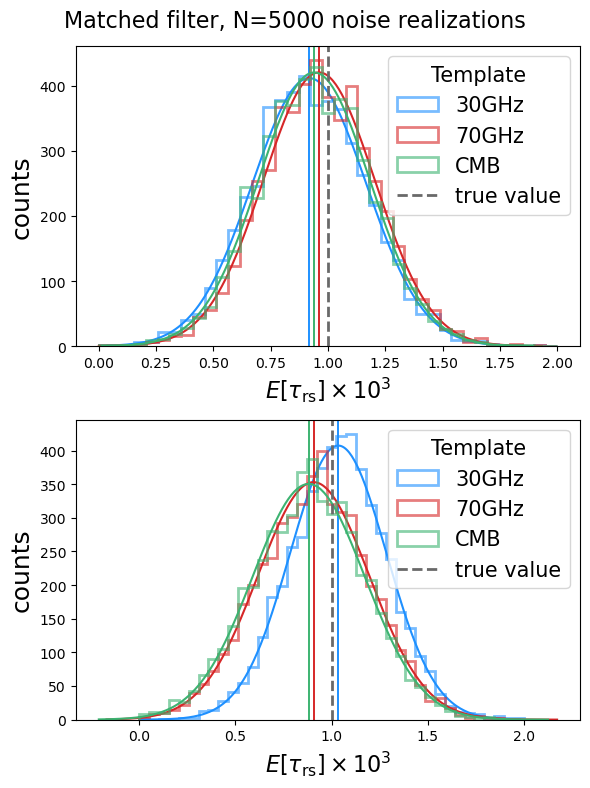

In [137]:
## build histogram 
from scipy.stats import norm

prob=False
if prob==True: #probability distribution
    ylabel=r'$\mathcal{P}$'
    renorm=1.
elif prob==False: #counts
    ylabel='counts'

N=len(tauN3[0])

def gen_bins(Nbins, data_list, center=None):
    if center is None:
        center = np.mean(np.concatenate(data_list))
    half_range=np.max(np.abs(np.concatenate(data_list)-center))
    bin_edges = np.linspace(center - half_range, center + half_range, Nbins)

    return bin_edges 


n_bins=40
print('Nº bins = ', n_bins-1)
print('counts = ', N)
bin_edges = gen_bins(n_bins, tauN3, center=1.) #nº of bins = n_nins-1      needs to be an odd number of bins --> Nbins even
bin_width = bin_edges[1] - bin_edges[0] #fit gaussian curves to the data 
if prob==False:
    renorm = N*bin_width

colors=['dodgerblue', 'tab:red', 'mediumseagreen']
colors2=['dodgerblue', 'tab:red', 'lightgreen']
labels=['30GHz', '70GHz', 'CMB']



fig, axes = plt.subplots(2, 1, figsize=(6, 8))
plt.suptitle('Matched filter, N='+str(N)+' noise realizations', fontsize=16)

#PLOT 1: NOISE only case 
print('\nNOISE ONLY CASE')
for i in range(3):
    axes[0].hist(tauN3[i], bins=bin_edges,  edgecolor=colors[i],  histtype='step', lw=2., density=prob, alpha=0.6, label=labels[i])
    #axes[0].axvline(tauB_arr[i], color=colors2[i], linestyle='--', lw=1.4) #BEAM ONLY tau VALUE 
    print(f'Template {i}: mean = {meanN3[i]:.4f}, std = {sigmaN3[i]:.4f}') 
    axes[0].axvline(meanN3[i], color=colors[i], linestyle='-', lw=1.4)
    x=np.linspace(np.min(tauN3[i]), np.max(tauN3[i]), 300)
    axes[0].plot(x, norm.pdf(x, meanN3[i], sigmaN3[i])*renorm, color=colors[i], lw=1.5)
    
#PLOT 1: NOISE + BEAM
print('\nNOISE + BEAM CASE')
for i in range(3):
    axes[1].hist(tauBN3[i], bins=bin_edges,  edgecolor=colors[i],  histtype='step', lw=2., density=prob, alpha=0.6, label=labels[i])
    #axes[1].axvline(tauB_arr[i], color=colors2[i], linestyle='--', lw=1.4) #BEAM ONLY tau VALUE 
    print(f'Template {i}: mean = {meanBN3[i]:.4f}, std = {sigmaBN3[i]:.4f}') 
    axes[1].axvline(meanBN3[i], color=colors[i], linestyle='-', lw=1.4)
    x=np.linspace(np.min(tauBN3[i]), np.max(tauBN3[i]), 300)
    axes[1].plot(x, norm.pdf(x, meanBN3[i], sigmaBN3[i])*renorm, color=colors[i], lw=1.5)
    

for ax in axes:
    ax.axvline(1., color='dimgray', linestyle='--', lw=2., label='true value')
    ax.set_xlabel(r'$E[\tau_{\rm{rs}}] \times 10^3$', fontsize=16)
    #ax.set_yscale('log')
    ax.set_ylabel(ylabel, fontsize=18)
    leg0=ax.legend( fontsize=15, title='Template')#bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=15, title='Template')
    leg0.get_title().set_fontsize(15)



plt.tight_layout()
plt.savefig('histograms.png', dpi=150)

plt.savefig("/home/evanetti/BEAMS/paper_figures/histograms.pdf", format="pdf", bbox_inches="tight")


plt.show()




In [144]:
### NOISE ONLY CASE:

N=5000 #number of noise realizations
lmin_tau=6 #lmin_bestN
lmax_tau=305 #lmax_bestN
tauN_list, sigmatauN_list=ftau.matched_filter_noise(map0symm, map1symm, beam0, beam1, map_cmb, sigmaN0, sigmaN1, lmin_tau, lmax_tau, N)

sigmadistN_list=[(tauN_list[i]-1.)/sigmatauN_list[i] for i in range(len(tauN_list))]
meanN_arr=[np.mean(tauN_list[i]) for i in range(3)]
sigma_meanN_arr=[np.std(tauN_list[i]) for i in range(3)]
print('tau_mean=', meanN_arr)
print('tau_sigma=', sigma_meanN_arr)

tau_mean= [0.9238113946442745, 0.9614875125746017, 0.9426315696017158]
tau_sigma= [0.24990738424557482, 0.2508636233665423, 0.25027526328636895]


In [138]:
print(tauN3[0])
print(tauN_list[0])

[1.06216801 1.09247108 0.76608218 0.5924456  0.89894728 0.73304731]
[0.91745976 0.73012472 1.32625823 0.7890721  0.88523367 0.75981524]


In [ ]:
compare_arr(tauN3[0], tauN_list[0])

### ERROR HERE?? 

min difference: -1.002840157115105
max difference: 0.7976055127993568
arrays are exacly equal:  False
arrays difference within 1e-07: False



0

In [40]:
### NOISE + BEAM CASE:

N=100 #number of noise realizations
lmin_tau=lmin_bestBN
lmax_tau=lmax_bestBN
tauBN_list, sigmatauBN_list=ftau.matched_filter_noise(map0, map1, beam0, beam1, map_cmb, sigmaN0, sigmaN1, lmin_tau, lmax_tau, N)

sigmadistBN_list=[(tauBN_list[i]-1.)/sigmatauBN_list[i] for i in range(len(tauBN_list))]
meanBN_arr=[np.mean(tauBN_list[i]) for i in range(3)]
sigma_meanBN_arr=[np.std(tauBN_list[i]) for i in range(3)]
print('tau_mean=', meanBN_arr)
print('tau_sigma=', sigma_meanBN_arr)

tau_mean= [1.0635890364068963, 0.5050628248860355, 0.41661562929527696]
tau_sigma= [0.209875075976357, 0.19901439771134014, 0.19943507185095935]


N =  100 realizations E[τ] results
╒════════════╤═══════════════════════╤═══════════════════════╤══════════════════════╕
│ Template   │ E[τ]mean Noise only   │ Noise+Beam: mean(τ)   │ Beam only: mean(τ)   │
╞════════════╪═══════════════════════╪═══════════════════════╪══════════════════════╡
│ 30GHz      │ (0.902 ± 0.250)×10⁻³  │ (1.064 ± 0.210)×10⁻³  │ (1.000 ± 0.027)×10⁻³ │
├────────────┼───────────────────────┼───────────────────────┼──────────────────────┤
│ 70GHz      │ (0.945 ± 0.255)×10⁻³  │ (0.505 ± 0.199)×10⁻³  │ (0.683 ± 0.027)×10⁻³ │
├────────────┼───────────────────────┼───────────────────────┼──────────────────────┤
│ CMB        │ (0.923 ± 0.252)×10⁻³  │ (0.417 ± 0.199)×10⁻³  │ (0.642 ± 0.027)×10⁻³ │
╘════════════╧═══════════════════════╧═══════════════════════╧══════════════════════╛
[0.  0.2 0.4]


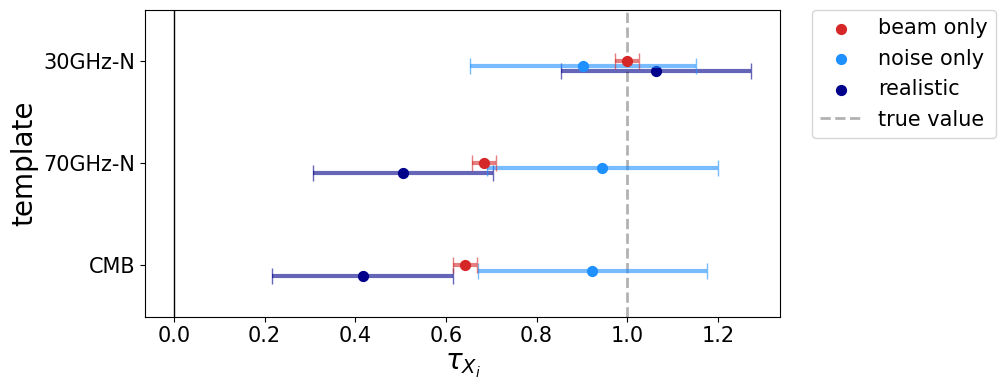

In [ ]:
### PLOT CENTRAL VALUES
templates=['30GHz','70GHz','CMB']
result_B = [f"({v:.3f} ± {e:.3f})×10⁻³" for v, e in zip(tauB_arr, sigmatauB_arr)]
result_N = [f"({v:.3f} ± {e:.3f})×10⁻³" for v, e in zip(meanN_arr, sigma_meanN_arr)]
result_BN = [f"({v:.3f} ± {e:.3f})×10⁻³" for v, e in zip(meanBN_arr, sigma_meanBN_arr)]

print('N = ', N, 'realizations E[τ] results' )
print(tabulate({ "Template": templates, "E[τ]mean Noise only": result_N, "Noise+Beam: mean(τ)": result_BN, "Beam only: mean(τ)": result_B }, headers="keys", tablefmt="fancy_grid"))  #tablefmt="grid", "fancy_grid", "rounded_outline"


cases=['30GHz-N','70GHz-N','CMB']

colors = ["tab:red", "dodgerblue", "darkblue"]  #beam only, noise only, realistic


y = np.arange(len(cases))
y=y/5
sh=np.array([0.01, 0.02, 0.03])
print(y)
fig, ax = plt.subplots(figsize=(8,4))
for i in range(len(cases)):
    ax.errorbar( tauB_arr[i], y[i], xerr=sigmatauB_arr[i], color=colors[0], ecolor=colors[0], markersize=8, elinewidth=3, capsize=6, alpha=0.6, zorder=2 ) #fmt='none'  #err bar options: width, lateral bar size, transparency
    ax.scatter( tauB_arr[i], y[i], color=colors[0], s=50, zorder=2, label='beam only'  if i==0 else '_nolegend_')


    ax.errorbar( meanN_arr[i], y[i]+0.01, xerr=sigma_meanN_arr[i], color=colors[1], ecolor=colors[1], elinewidth=3, capsize=6, alpha=0.6, zorder=1 ) #fmt='none'  #err bar options: width, lateral bar size, transparency
    ax.scatter( meanN_arr[i], y[i]+0.01, color=colors[1], s=50,  zorder=1, label='noise only' if i==0 else '_nolegend_')
    
    ax.errorbar( meanBN_arr[i], y[i]+0.02, xerr=sigma_meanBN_arr[i], color=colors[2], ecolor=colors[2], elinewidth=3, capsize=6, alpha=0.6, zorder=0 ) #fmt='none'  #err bar options: width, lateral bar size, transparency
    ax.scatter( meanBN_arr[i], y[i]+0.02, color=colors[2], s=50,  zorder=0, label='realistic' if i==0 else '_nolegend_' )

#ax.set_xticks([- 4, -3, -2, -1, 0., 1, 2, 3, 4])
ax.tick_params(axis='x', labelsize=15)
ax.set_yticks(y)
ax.set_yticklabels(cases, fontsize=15)
ax.set_xlabel(r"$\tau_{X_i}$", fontsize=20)
ax.set_ylabel(r"template", fontsize=20)

#ax.set_xlim(- 0.0035, 0.0045) 
ax.set_ylim(y[0]-0.1, y[-1]+0.1)
ax.axvline(1., color='black', linestyle='--', linewidth=2, alpha=0.3, label='true value', zorder=0)  # Vertical reference line
ax.axvline(0., color='black', linestyle='-', linewidth=1., zorder=0)  # Vertical reference line


ax.invert_yaxis()
fig.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=15)

plt.savefig("/home/evanetti/BEAMS/paper_figures/matched_filtering.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [554]:
print('\n\nDeviation of mean(τ) from true value')
print(tabulate({ "Template": templates, 
                "N: mean(τ)-1": np.array(meanN_arr)-1.,  
                "N: σ/√N": np.array(sigma_meanN_arr)/np.sqrt(N), 
                "N+B: mean(τ)-1.": np.array(meanBN_arr)-1.,
                "N+B: σ/√N": np.array(sigma_meanBN_arr)/np.sqrt(N), 
                }, 
                headers="keys", tablefmt="fancy_grid", floatfmt=".4f"))  #tablefmt="grid", "fancy_grid", "rounded_outline"



Deviation of mean(τ) from true value
╒════════════╤════════════════╤═══════════╤═══════════════════╤═════════════╕
│ Template   │   N: mean(τ)-1 │   N: σ/√N │   N+B: mean(τ)-1. │   N+B: σ/√N │
╞════════════╪════════════════╪═══════════╪═══════════════════╪═════════════╡
│ 30GHz      │        -0.0042 │    0.0265 │            0.0636 │      0.0210 │
├────────────┼────────────────┼───────────┼───────────────────┼─────────────┤
│ 70GHz      │         0.0374 │    0.0265 │           -0.4949 │      0.0199 │
├────────────┼────────────────┼───────────┼───────────────────┼─────────────┤
│ CMB        │         0.0152 │    0.0264 │           -0.5834 │      0.0199 │
╘════════════╧════════════════╧═══════════╧═══════════════════╧═════════════╛


In [146]:
## FUNCTION: to build histogram 
from scipy.stats import norm

def gen_bins(Nbins, data_list, center=None):
    if center is None:
        center = np.mean(np.concatenate(data_list))
    half_range=np.max(np.abs(np.concatenate(data_list)-center))
    bin_edges = np.linspace(center - half_range, center + half_range, Nbins)

    return bin_edges 

def tau_hist(tau_list, sigmatau_list, sigmadist_list, n_bins):
    
    print('Nº bins = ', n_bins-1)
    print('counts = ', len(tau_list[0]))

    prob=False
    if prob==True: #probability distribution
        ylabel=r'$\mathcal{P}$'
        renorm=1.
    elif prob==False: #counts
        ylabel='counts'

    colors=['dodgerblue', 'tomato', 'mediumseagreen']
    colors2=['dodgerblue', 'tomato', 'lightgreen']
    labels=['30GHz', '70GHz', 'CMB']

    N=len(tau_list[0])
    

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

    plt.suptitle('Matched filter, N = ' + str(N) + ',  noise realizations', fontsize=16)

    bin_edges0 = gen_bins(n_bins, tau_list, center=1.) #nº of bins = n_nins-1      needs to be an odd number of bins --> Nbins even
    bin_width = bin_edges0[1] - bin_edges0[0] #fit gaussian curves to the data 
    if prob==False:
        renorm = N*bin_width

    for i in range(3):
        axes[0].hist(tau_list[i], bins=bin_edges0,  edgecolor=colors[i],  histtype='step', lw=2., density=prob, alpha=0.6)
        #axes[0].axvline(tauB_arr[i], color=colors2[i], linestyle='--', lw=1.4) #BEAM ONLY tau VALUE 

        mean = np.mean(tau_list[i])
        sigma = np.std(tau_list[i])
        print(f'Template {i}: mean = {mean:.4f}, std = {sigma:.4f}') 
        axes[0].axvline(mean, color=colors[i], linestyle='-', lw=1.4)
        x=np.linspace(np.min(tau_list[i]), np.max(tau_list[i]), 300)
        axes[0].plot(x, norm.pdf(x, mean, sigma)*renorm, color=colors[i], lw=1.5)
        
    axes[0].axvline(1., color='dimgray', linestyle='--', lw=2.)
    #axes[0].axvspan(1.- sigma/np.sqrt(N), 1.+ sigma/np.sqrt(N), color='gray', alpha=0.3)
    axes[0].set_xlabel(r'$E[\tau] \times 10^3$', fontsize=16)


    bin_edges1 = gen_bins(n_bins, sigmatau_list) #nº of bins = n_nins-1      needs to be an odd number of bins --> Nbins even
    axes[1].hist(sigmatau_list[0], bins=bin_edges1,  edgecolor=colors[0], histtype='step', lw=2., density=prob)
    axes[1].hist(sigmatau_list[1], bins=bin_edges1,  edgecolor=colors[1], histtype='step', lw=2., density=prob)
    #axes[1].hist(sigmatau_list[2], bins=bin_edges1,  edgecolor=colors[2], histtype='step', lw=2., density=prob)
    axes[1].set_xlabel(r'$\sigma_\tau \times 10^3$', fontsize=16)

    bin_edges2 = gen_bins(n_bins, sigmadist_list, center=0) #nº of bins = n_nins-1      needs to be an odd number of bins --> Nbins even
    axes[2].hist(sigmadist_list[0], bins=bin_edges2, edgecolor=colors[0], histtype='step', lw=2., label=labels[0], density=prob)
    axes[2].hist(sigmadist_list[1], bins=bin_edges2,edgecolor=colors[1], histtype='step', lw=2., label=labels[1], density=prob)
    #axes[2].hist(sigmadist_list[2], bins=bin_edges2,edgecolor=colors[2], histtype='step', lw=2., label=labels[2], density=prob)
    axes[2].axvline(0., color='dimgray', linestyle='--', lw=2.)
    #for i in range(3):
    #    axes[2].axvline(sigmadistB_arr[i], color=colors2[i], linestyle='-', lw=1.4, label='Beam only '+labels[i]) #BEAM ONLY sigma-tau VALUE 
    axes[2].set_xlabel(r'$\sigma$-distance', fontsize=16)


    for ax in axes:
        ax.set_yscale('log')
        ax.set_ylabel(ylabel, fontsize=18)

    leg=plt.legend( bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=15, title='Template')
    leg.get_title().set_fontsize(15)
    plt.tight_layout()
    plt.savefig('histograms.png', dpi=150)
    plt.show()

    return 0

In [556]:
def scott_bins(data):
    N = len(data)
    sigma = np.std(data, ddof=1)  # sample std with Bessel correction
    
    bin_width = 3.49 * sigma / N**(1/3)
    n_bins = int(np.ceil((data.max() - data.min()) / bin_width))
    
    return n_bins
print('Nº bins = ', scott_bins(tauN_list[0]), '  optimal for gaussian distrinution')

Nº bins =  7   optimal for gaussian distrinution


Nº bins =  39
counts =  100
Template 0: mean = 1.0636, std = 0.2099
Template 1: mean = 0.5051, std = 0.1990
Template 2: mean = 0.4166, std = 0.1994


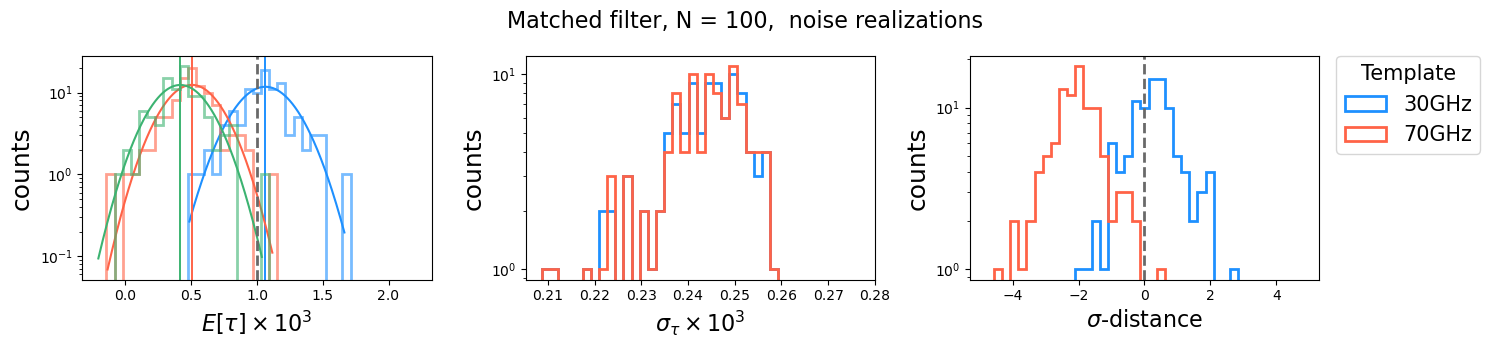

100
Nº bins =  39
counts =  100
Template 0: mean = 0.9958, std = 0.2646
Template 1: mean = 1.0374, std = 0.2654
Template 2: mean = 1.0152, std = 0.2640


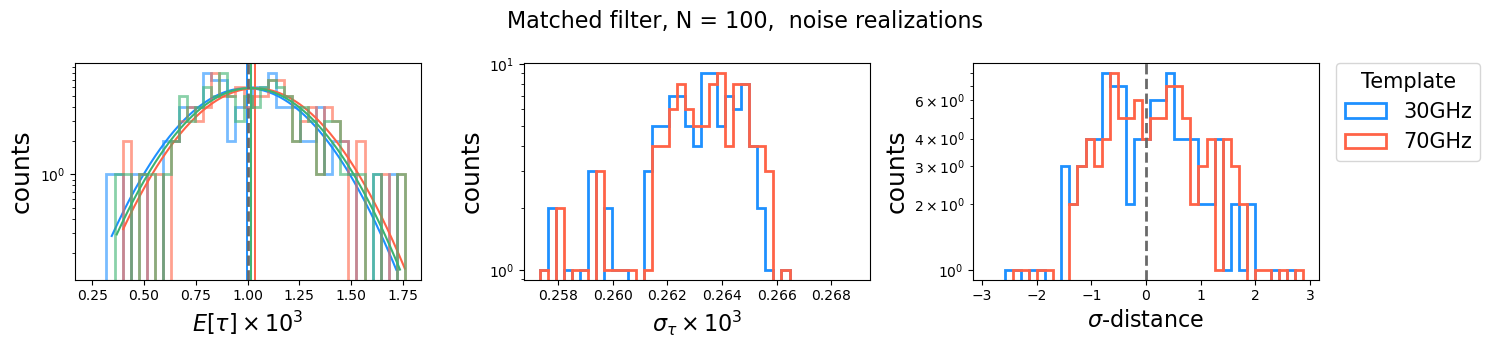

0

In [557]:
n_bins=40
tau_hist(tauBN_list, sigmatauBN_list, sigmadistBN_list, n_bins)
print(len(tauN_list[0]))
tau_hist(tauN_list, sigmatauN_list, sigmadistN_list, n_bins)


mean = 0.7843, std = 0.2030


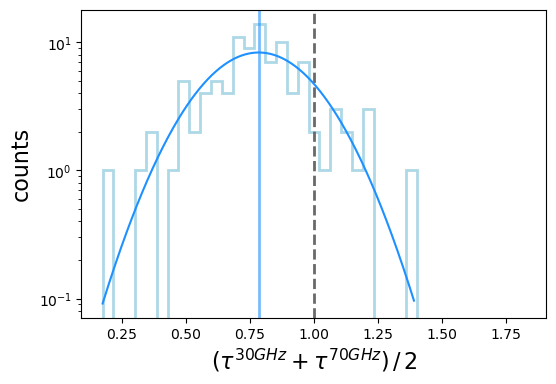

In [402]:
#### BIAS SOLUTION ATTEMPT: average results of 2 templates
tau_avg=(tauBN_list[0]+tauBN_list[1])/2
mean = np.mean(tau_avg)
sigma = np.std(tau_avg)
print(f'mean = {mean:.4f}, std = {sigma:.4f}') 

n_bins=40
bin_edges = gen_bins(n_bins, [tau_avg, tau_avg], center=1.) #nº of bins = n_nins-1      needs to be an odd number of bins --> Nbins even
bin_width = bin_edges[1] - bin_edges[0] #fit gaussian curves to the data 
renorm = N*bin_width


plt.figure(figsize=(6, 4))
plt.hist(tau_avg, bins=bin_edges, density=False, edgecolor='lightblue',  histtype='step', lw=2., alpha=1.)
plt.axvline(mean, color='dodgerblue', linestyle='-', lw=2., alpha=0.6)
plt.axvline(1., color='dimgray', linestyle='--', lw=2.)

x=np.linspace(np.min(tau_avg), np.max(tau_avg), 300)
plt.plot(x, norm.pdf(x, mean, sigma)*renorm, color='dodgerblue', lw=1.5)
plt.yscale('log')
plt.xlabel(r"$(\tau^{30 GHz}+\tau^{70 GHz})\,/\,2$", fontsize=16)
plt.ylabel("counts", fontsize=16)
plt.show()


mean = 0.7843, std = 0.2030
mean = 0.5585, std = 0.0502


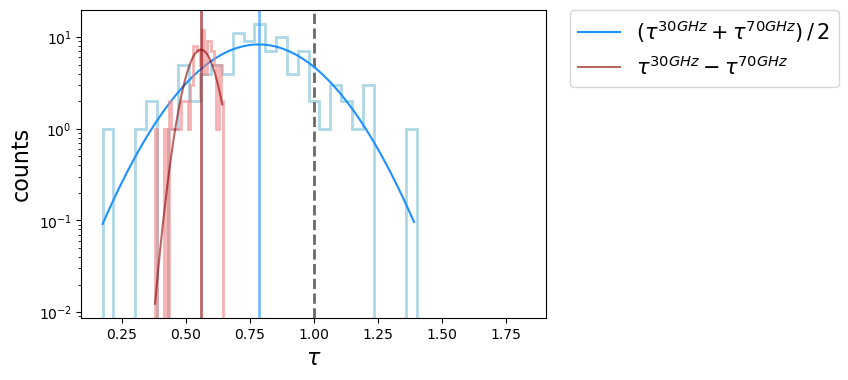

In [403]:
#### BIAS SOLUTION ATTEMPT: average results of 2 templates
tau_avg=(tauBN_list[0]+tauBN_list[1])/2
mean = np.mean(tau_avg)
sigma = np.std(tau_avg)
print(f'mean = {mean:.4f}, std = {sigma:.4f}') 

n_bins=40
bin_edges = gen_bins(n_bins, [tau_avg, tau_avg], center=1.) #nº of bins = n_nins-1      needs to be an odd number of bins --> Nbins even
bin_width = bin_edges[1] - bin_edges[0] #fit gaussian curves to the data 
renorm = N*bin_width


plt.figure(figsize=(6, 4))
plt.hist(tau_avg, bins=bin_edges, density=False, edgecolor='lightblue',  histtype='step', lw=2., alpha=1.)
plt.axvline(mean, color='dodgerblue', linestyle='-', lw=2., alpha=0.6)
plt.axvline(1., color='dimgray', linestyle='--', lw=2.)

x=np.linspace(np.min(tau_avg), np.max(tau_avg), 300)
plt.plot(x, norm.pdf(x, mean, sigma)*renorm, color='dodgerblue', lw=1.5, label=r"$(\tau^{30 GHz}+\tau^{70 GHz})\,/\,2$")


########################################################3
diff_tau=tauBN_list[0]-tauBN_list[1]
mean_ = np.mean(diff_tau)
sigma_ = np.std(diff_tau)
print(f'mean = {mean_:.4f}, std = {sigma_:.4f}') 

bin_edges_ = gen_bins(n_bins, [diff_tau, diff_tau]) #nº of bins = n_nins-1      needs to be an odd number of bins --> Nbins even
bin_width_ = bin_edges_[1] - bin_edges_[0] #fit gaussian curves to the data 
renorm_ = N*bin_width_
plt.hist(diff_tau, bins=bin_edges_, density=False, edgecolor='lightcoral',  histtype='step', lw=2., alpha=0.6)
plt.axvline(mean_, color='darkred', linestyle='-', lw=2., alpha=0.6)

x=np.linspace(np.min(diff_tau), np.max(diff_tau), 300)
plt.plot(x, norm.pdf(x, mean_, sigma_)*renorm_, color='darkred', lw=1.5, alpha=0.6, label=r"$\tau^{30 GHz}-\tau^{70 GHz}$")
plt.yscale('log')
plt.xlabel(r"$\tau$", fontsize=16)
plt.legend( bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=15)
plt.ylabel("counts", fontsize=16)
plt.show()

In [ ]:

l_range=np.arange(lmin, lmax+1)

##color plot 
cbar_height=0.2

fig, axes = plt.subplots(1, 3, figsize=(16, 3))

# --- left plot: result_sigma_tau ---
im1 = axes[0].imshow(sigmaBN_grid, origin='lower', cmap='inferno_r',
                     #vmin=np.nanmin(result_sigma_tau), vmax=np.nanmax(result_sigma_tau)  ## NOISELESS MAPSYMM
                     vmin=np.nanmin(sigmaBN_grid), vmax=0.4  #NOISELESS  +  beam residuals
                     )
axes[0].scatter(tau_bestBN['lmax'][0], tau_bestBN['lmin'][0],
                marker='*', s=300, c='lime', edgecolors='black',
                label='optimal')
plt.colorbar(im1, ax=axes[0], shrink=cbar_height, aspect=10)
axes[0].set_xlabel(r'$\ell_{\rm max}$', fontsize=20)
axes[0].set_ylabel(r'$\ell_{\rm min}$', fontsize=20)
axes[0].set_title(r'$\sigma_\tau$', fontsize=20)

# --- right plot: result_tau ---
tau_th=1.
delta=0.8
im2 = axes[1].imshow(tauBN_grid, origin='lower', cmap='RdBu',
                     vmin=tau_th-delta, vmax=tau_th+delta
                     )
axes[1].scatter(tau_bestBN['lmax'][0], tau_bestBN['lmin'][0],
                marker='*', s=300, c='lime', edgecolors='black',
                label='optimal')
plt.colorbar(im2, ax=axes[1], shrink=cbar_height, aspect=10)
axes[1].set_xlabel(r'$\ell_{\rm max}$', fontsize=20)
axes[1].set_ylabel(r'$\ell_{\rm min}$', fontsize=20)
axes[1].set_title(r'$\tau$', fontsize=20)

# --- center plot: MSqE ---
#im3 = axes[2].imshow(MSqE_grid, origin='lower', cmap='inferno_r',
#                     vmin=np.nanmin(MSqE_grid), vmax=0.005
#                     )

im3 = axes[2].imshow(MSqE_BNgrid, origin='lower', cmap='inferno_r',
                     norm=LogNorm(vmin=np.nanmin(MSqE_BNgrid), vmax=np.nanmax(MSqE_BNgrid)) 
                     )

axes[2].scatter(tau_bestBN['lmax'][0], tau_bestBN['lmin'][0],
                marker='*', s=300, c='lime', edgecolors='black',
                label='optimal')
plt.colorbar(im3, ax=axes[2], shrink=cbar_height, aspect=10)
axes[2].set_xlabel(r'$\ell_{\rm max}$', fontsize=20)
axes[2].set_ylabel(r'$\ell_{\rm min}$', fontsize=20)
axes[2].set_title(r'$\tau$', fontsize=20)

plt.tight_layout()
plt.show()

BEAM ONLY: 

sigma_min=0.0325, sigma_max=12.9491

OPTIMAL sigma: lmin=20, lmax=650, tau=1.090266, sigma=0.032450

tau_min=-9.1194, tau_max=118.4745

OPTIMAL tau: lmin=99, lmax=115, tau=1.000001, sigma=0.242583

# SEPARATION LINE ____________________________________________________________________________


ATTEMPT: further noise subtraction --> on template Cls, on covariance? 

is there correlation due to the fact that both diff map and template are deconvolved with a beam? 

interpret the bias. 


MATCHED FILTER from alms: 

improve: start from beam maps [need an additional function to normalize beams]

improve: take only freq. as imput and read everything elseCls_beam0_cut


CHECKS: 
1) done: results for beam only case are the same as in map level computations 
2) to do: check noise case results with map level computations (need same noise realization!)

In [ ]:
### create noise maps:
npix=hp.nside2npix(nside) # generate noise map
map_noise0 = np.random.normal(loc=0.0, scale=sigmaN0, size=npix)
map_noise1 = np.random.normal(loc=0.0, scale=sigmaN1, size=npix)
map_noise10=map_noise1-map_noise0  

In [ ]:
### CHECK: that alm noise is generated correctly
ClsN0= hp.alm2cl(almsN0_)
Cls_mapN0=hp.anafast(map_noise0, lmax=lmax_beam, use_pixel_weights=True)

plt.plot(ll_cut, Cls_noise30_, label='noise alms', color='dodgerblue')
plt.plot(ll_cut, Cls_map_noise30_, label='noise maps', color='red', alpha=0.5)
plt.hlines(level_Clsnoise0, ll_cut[0], ll_cut[-1], lw=2, colors='k', linestyles='dashed', label=r'$\sigma_{\rm{pix}}^2\Delta\Omega_{\rm{pix}}$')
plt.legend(fontsize=16)
plt.xlabel(r'$\ell$', fontsize=20)
plt.ylabel(r'$C_\ell$', fontsize=20)
plt.title(r'Noise $a_{\ell m}$', fontsize=16)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [ ]:
### CHECK RESULTS 
print('E[tau]x10³ \t sigma_tau [x10³] \t sigma-dist')
for i in range(10):
    print(f'{tau_arr[i]*1e3:.3f}\t\t  {sigmatau_arr[i]*1e3:.3f} \t\t{(tau_arr[i]-0.001)/sigmatau_arr[i]:.2f}')

In [ ]:
alm_map0=hp.map2alm(map0, lmax=lmax_beam) #do once out of function 
alm_map1=hp.map2alm(map1, lmax=lmax_beam)
#map_list=[map0, map1, map0-map1]
#alm_maps=hp.map2alm(map_list, lmax=lmax_beam)

bl0_inv=1/np.sqrt(Cls_beam0_cut) ### NOTA: CLs_beam need to be cut to lmin_tau, lmax_tau
bl1_inv=1/np.sqrt(Cls_beam1_cut)

In [ ]:
alm_map0_n=alm_map0+alms30  #add noise to maps
alm_map1_n=alm_map1+alms70

alm_map0_dec=hp.almxfl(alm_map0_n, bl0_inv)  #deconvolve 
alm_map1_dec=hp.almxfl(alm_map1_n, bl1_inv)   
alm_mapdiff=alm_map0_dec-alm_map1_dec #--> DATA for matched filter

In [ ]:
#### TEST: do matched filter with alms for noiseless case and see if result is the same

alm_data=alm_mapdiff
alm_template=alm_map0_dec

Cl_data=hp.alm2cl(alm_data)  #can add lmax, lmax_out
Cl_template=hp.alm2cl(alm_template)  #template is clean map
Cl_cross=hp.alm2cl(alm_data, alm_template)


In [ ]:
Cl_cov=Cl_data
lmin_tau=50
lmax_tau=250

t, s = tau_estimate_alms(Cl_cross, Cl_template, Cl_cov, lmin_tau, lmax_tau)
print(t*1e3,s*1e3)

In [ ]:
### CHECK: that alm noise is generated correctly
Cls_noise30_= hp.alm2cl(alms30)
Cls_map_noise30_=hp.anafast(map_noise0, lmax=lmax_beam, use_pixel_weights=True)

plt.plot(ll_cut, Cls_noise30_, label='noise alms', color='dodgerblue')
plt.plot(ll_cut, Cls_map_noise30_, label='noise maps', color='red', alpha=0.5)
plt.hlines(level_Clsnoise0, ll_cut[0], ll_cut[-1], lw=2, colors='k', linestyles='dashed', label=r'$\sigma_{\rm{pix}}^2\Delta\Omega_{\rm{pix}}$')
plt.legend(fontsize=16)
plt.xlabel(r'$\ell$', fontsize=20)
plt.ylabel(r'$C_\ell$', fontsize=20)
plt.title(r'Noise $a_{\ell m}$', fontsize=16)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [ ]:
def tau_estimate_alms(Cl_cross, Cl_template, Cl_cov, lmin_tau, lmax_tau): 
    l=np.arange(lmin_tau, lmax_tau)
    nom_l=(2*l+1)*Cl_cross[lmin_tau:lmax_tau]/Cl_cov[lmin_tau:lmax_tau]
    denom_l=(2*l+1)*Cl_template[lmin_tau:lmax_tau]/Cl_cov[lmin_tau:lmax_tau]
    tauE=np.sum(nom_l)/np.sum(denom_l)
    sigma_tauE=np.sqrt(1/np.sum(denom_l) )

    return tauE, sigma_tauE

## Prepare maps 

In [ ]:
### REAL BEAM + NOISE:
map0_n=map0+map_noise0 #add noise
map1_n=map1+map_noise1

map0_n_dec=hp.sphtfunc.smoothing(map0_n, beam_window=1/np.sqrt(Cls_beam0_cut), lmax=lmax_beam)  # deconvolve noisy maps
map1_n_dec=hp.sphtfunc.smoothing(map1_n, beam_window=1/np.sqrt(Cls_beam1_cut), lmax=lmax_beam)
map10_n=map0_n_dec-map1_n_dec


### REAL BEAM, NOISELESS
map0_dec=hp.sphtfunc.smoothing(map0, beam_window=1/np.sqrt(Cls_beam0_cut), lmax=lmax_beam)  # deconvolve initial maps
map1_dec=hp.sphtfunc.smoothing(map1, beam_window=1/np.sqrt(Cls_beam1_cut), lmax=lmax_beam)
map10=map0_dec-map1_dec


### SYMM BEAM + NOISE: convolve maps with symmetrized beam, in harmonic space 
map0symm=hp.sphtfunc.smoothing(map_cmb, beam_window=np.sqrt(Cls_beam0_cut), lmax=lmax_beam) #convolve with symmetrized beams
map1symm=hp.sphtfunc.smoothing(map_xi, beam_window=np.sqrt(Cls_beam1_cut), lmax=lmax_beam)

map0symm_n=map0symm+map_noise0 #add noise
map1symm_n=map1symm+map_noise1

map0symm_n_dec=hp.sphtfunc.smoothing(map0symm_n, beam_window=1/np.sqrt(Cls_beam0_cut), lmax=lmax_beam)  # deconvolve noisy maps
map1symm_n_dec=hp.sphtfunc.smoothing(map1symm_n, beam_window=1/np.sqrt(Cls_beam1_cut), lmax=lmax_beam)
map10symm_n=map0symm_n_dec-map1symm_n_dec 

In [ ]:
###############################
### Cls of deconvolved maps ###
###############################

### REAL BEAM + NOISE:
Cls_map0_n_dec=hp.anafast(map0_n_dec, lmax=lmax_beam, use_pixel_weights=True) 
Cls_map1_n_dec=hp.anafast(map1_n_dec, lmax=lmax_beam, use_pixel_weights=True)
Cls_map10_n=hp.anafast(map10_n, lmax=lmax_beam, use_pixel_weights=True)

### REAL BEAM, NOISELESS
Cls_map0_dec=hp.anafast(map0_dec, lmax=lmax_beam, use_pixel_weights=True)
Cls_map1_dec=hp.anafast(map1_dec, lmax=lmax_beam, use_pixel_weights=True)
Cls_map10=hp.anafast(map10, lmax=lmax_beam, use_pixel_weights=True)

### SYMM BEAM + NOISE:
Cls_map0symm_n_dec=hp.anafast(map0symm_n_dec, lmax=lmax_beam, use_pixel_weights=True) 
Cls_map1symm_n_dec=hp.anafast(map1symm_n_dec, lmax=lmax_beam, use_pixel_weights=True)
Cls_map10symm_n=hp.anafast(map10symm_n, lmax=lmax_beam, use_pixel_weights=True)

In [ ]:
## plot histogram of tau values


In [ ]:
#Theory Cls: 
Cls_map_cmb=hp.anafast(map_cmb, lmax=lmax_beam, use_pixel_weights=True)
Cls_map_xi=hp.anafast(map_xi, lmax=lmax_beam, use_pixel_weights=True)

mapdiff_th=map_cmb-map_xi
Cls_mapdiff_th=hp.anafast(mapdiff_th, lmax=lmax_beam, use_pixel_weights=True)

In [ ]:
## CROSS: diff map x 30 GHz map
Cls_cross_real_n = hp.anafast(map10_n, map0_n_dec, lmax=lmax_beam, use_pixel_weights=True)
Cls_cross_real = hp.anafast(map10, map0_dec, lmax=lmax_beam, use_pixel_weights=True)
Cls_cross_symm_n = hp.anafast(map10symm_n, map0symm_n_dec, lmax=lmax_beam, use_pixel_weights=True)
Cls_cross_th = hp.anafast(mapdiff_th, map_cmb, lmax=lmax_beam, use_pixel_weights=True)

## noise subtraction
Cls_cross_real_n_ = Cls_cross_real_n-level_Clsnoise0_dec
Cls_cross_symm_n_ = Cls_cross_symm_n-level_Clsnoise0_dec

# Matched filtering

In [ ]:
#1) Matched filter with covariance approx. by the data
def tau_estimate(map_data, map_template, lmin_tau, lmax_tau, Cls_cov=None, Cls_noise=None, plot=False):
    '''
    Args: 
    - map_data: difference map between 2 different frequency channels, containing signal+noise+sysrematics+foregrouds
    - map_template: opt.1) map for a clean frequency    opt.2) CMB map obtained from component separation
    - lmin_tau, lmax_tau: multipole range for tau estimation
    - (opt)Cls_cov: covariance for the matched filter. If not provided, use Cls_data (APPROX)  
    - (opt)Cls_noise: noise for Cls_cross (data x template). If not provided, no noise subtraction is applied.
    '''

    Cl_template=hp.anafast(map_template, lmax=lmax_tau)  #TEMPLATE: Cls of clean map // Cls CMB
    Cl_data=hp.anafast(map_data, lmax=lmax_tau)      #DATA: difference map between two frequencies
    Cl_cross=hp.anafast(map_data, map_template, lmax=lmax_tau)     #cross-Cls of DATA x TEMPLATE
    
    if Cls_cov is None: 
        cov=Cl_data #default: 1) approx Cl_cov=Cl_data (if covariance is not provided)   
        cov_info='Cls_cov=Cls_data'

    else: 
        cov=Cls_cov[:lmax_tau+1] #if Cls_cov is provided use that. Cases 2)use known noise statistics and 3)test with real data covariance
        cov_info='Cls_cov=Provided'

    sn=''
    if Cls_noise is not None:  #noise subtraction
        Cl_cross=Cl_cross-Cls_noise[:lmax_tau+1]
        sn=' noise subtracted'
    

    l=np.arange(lmax_tau+1)   
    
    #matched filter equation:Cls_noise
    nom_l=(2*l[lmin_tau:]+1)*Cl_cross[lmin_tau:]/cov[lmin_tau:]
    denom_l=(2*l[lmin_tau:]+1)*Cl_template[lmin_tau:]/cov[lmin_tau:]
    tauE=sum(nom_l)/sum(denom_l)
    sigma_tauE=np.sqrt(1/sum(denom_l))

    #compute sigma distance: 
    tau_th=1e-3
    sigma_dist=abs(tauE-tau_th)/sigma_tauE
    print(f'E[tau] = ({tauE*1e3:.3f}±{sigma_tauE*1e3:.3f})x10⁻³  \t sigma dist: {sigma_dist:.3f}\t err. interval: [{(tauE-sigma_tauE)*1e3:.3f}-{(tauE+sigma_tauE)*1e3:.3f}]x10⁻³ {sn}, {cov_info}')


    if plot==True:

        print(f'nom={sum(nom_l):.3e} \t denom={sum(denom_l):.3e}')

        plt.figure(figsize=(11,3.5))
        #plt.plot(l[lmin_tau:], Cl_cross[lmin_tau:]/cov[lmin_tau:], label=r'$C_\ell^{\rm{cross}}/C_\ell^{\rm{cov}}$', color='tab:red', ls='--')
        plt.plot(l[lmin_tau:], (2*l[lmin_tau:]+1)*Cl_cross[lmin_tau:]/cov[lmin_tau:], label=r'$(2\ell+1)C_\ell^{\rm{cross}}/C_\ell^{\rm{cov}}$', color='red') 
        plt.hlines(sum(nom_l), l[lmin_tau] , l[-1], color='red', ls=':', lw=2.,  alpha=0.3)  

        #plt.plot(l[lmin_tau:], Cl_template[lmin_tau:]/cov[lmin_tau:], label=r'$C_\ell^{\rm{temp}}/C_\ell^{\rm{cov}}$', color='darkblue', ls='--')  #deconvolved 30GHz map
        plt.plot(l[lmin_tau:], (2*l[lmin_tau:]+1)*Cl_template[lmin_tau:]/cov[lmin_tau:], label=r'$(2\ell+1)C_\ell^{\rm{temp}}/C_\ell^{\rm{cov}}$', color='blue', ls='-')
        plt.hlines(sum(denom_l), l[lmin_tau] , l[-1], color='blue', ls=':', lw=2., alpha=0.3)  


        plt.hlines(0., l[lmin_tau] , l[-1], color='black', ls='--', lw=1) 

        plt.xscale('linear')
        plt.yscale('symlog', linthresh=1e-5)
        plt.xlabel(r'$\ell$', fontsize=18)
        plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
        plt.legend( bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=13)
        plt.tight_layout()
        plt.show()

    return tauE, sigma_tauE

In [ ]:
lmin_tau=50
lmax_tau=250

# REALISTIC BEAM, NOISELESS
print('\nRealistic beam (noiseless)')
tauB_cmb, sigma_tauB_cmb=tau_estimate(map10, map_cmb, lmin_tau, lmax_tau)
tauB_30, sigma_tauB_30=tau_estimate(map10, map0_dec, lmin_tau, lmax_tau)
tauB_70, sigma_tauB_70=tau_estimate(map10, map1_dec, lmin_tau, lmax_tau)

# SYMMETRIC NOISE
print('\nSymmetric noise only')
tauN_cmb, sigma_tauN_cmb=tau_estimate(map10symm_n, map_cmb, lmin_tau,  lmax_tau)
tauN_30, sigma_tauN_30=tau_estimate(map10symm_n, map0symm_n_dec, lmin_tau,  lmax_tau)
tauN_30subtr, sigma_tauN_30subtr=tau_estimate(map10symm_n, map0symm_n_dec, lmin_tau,  lmax_tau, Cls_noise=level_Clsnoise0_dec)
tauN_70, sigma_tauN_70=tau_estimate(map10symm_n, map1symm_n_dec, lmin_tau,  lmax_tau)
tauN_70subtr, sigma_tauN_70subtr=tau_estimate(map10symm_n, map1symm_n_dec, lmin_tau,  lmax_tau, Cls_noise=-level_Clsnoise1_dec)

# REALISTIC BEAM + NOISE
print('Realistic beam + noise')
tauBN_cmb, sigma_tauBN_cmb=tau_estimate(map10_n, map_cmb, lmin_tau, lmax_tau)  
tauBN_30, sigma_tauBN_30=tau_estimate(map10_n, map0_n_dec, lmin_tau, lmax_tau)  
tauBN_30subtr, sigma_tauBN_30subtr=tau_estimate(map10_n, map0_n_dec, lmin_tau, lmax_tau, Cls_noise=level_Clsnoise0_dec)  
tauBN_70, sigma_tauBN_70=tau_estimate(map10_n, map1_n_dec, lmin_tau, lmax_tau)  
tauBN_70subtr, sigma_tauBN_70subtr=tau_estimate(map10_n, map1_n_dec, lmin_tau, lmax_tau, Cls_noise=-level_Clsnoise1_dec)  


In [ ]:
from tabulate import tabulate
import pandas as pd

In [ ]:
### visualize results 
cases = ["CMB", "30GHz", "70GHz", "30GHz-N", "70GHz-N"]

tauB=np.array([tauB_cmb, tauB_30, tauB_70, np.nan, np.nan])
tauN=np.array([tauN_cmb, tauN_30, tauN_70, tauN_30subtr, tauN_70subtr])
tauBN=np.array([tauBN_cmb, tauBN_30, tauBN_70, tauBN_30subtr, tauBN_70subtr])

sigma_tauB=np.array([sigma_tauB_cmb, sigma_tauB_30, sigma_tauB_70, np.nan, np.nan])
sigma_tauN=np.array([sigma_tauN_cmb, sigma_tauN_30, sigma_tauN_70, sigma_tauN_30subtr, sigma_tauN_70subtr])
sigma_tauBN=np.array([sigma_tauBN_cmb, sigma_tauBN_30, sigma_tauBN_70, sigma_tauBN_30subtr, sigma_tauBN_70subtr])

result_B_ = [f"{v*1e3:.3f} ± {e*1e3:.3f}" for v, e in zip(tauB, sigma_tauB)]
result_N_ = [f"{v*1e3:.3f} ± {e*1e3:.3f}" for v, e in zip(tauN, sigma_tauN)]
result_BN_ = [f"{v*1e3:.3f} ± {e*1e3:.3f}" for v, e in zip(tauBN, sigma_tauBN)]

tau_true=0.001
biasB=tauB-tau_true
biasN=tauN-tau_true
biasBN=tauBN-tau_true

sigmadistB=np.abs(biasB)/sigma_tauB
sigmadistN=np.abs(biasN)/sigma_tauN
sigmadistBN=np.abs(biasBN)/sigma_tauBN

idxB = np.nanargmin(sigmadistB)
idxN = np.nanargmin(sigmadistN)
idxBN = np.nanargmin(sigmadistBN)

arrays = [
    ["Template", "beam only",    "beam only",    "beam only",    "noise only",   "noise only",   "noise only",   "beam+noise", "beam+noise", "beam+noise"],
    ["",         "E[tau][×10⁻³]",  "b[×10⁻³]",    "σ_dist",  "E[tau][×10⁻³]",  "b[×10⁻³]",    "σ_dist",  "E[tau][×10⁻³]",     "b[×10⁻³]",       "σ_dist"] 
    ]
multi_col = pd.MultiIndex.from_arrays(arrays)
data = list(zip(cases, result_B_, biasB*1e3, sigmadistB, result_N_, biasN*1e3, sigmadistN, result_BN_, biasBN*1e3, sigmadistBN))   
df = pd.DataFrame(data, columns=multi_col)

# format bias and sigma_dist columns
for group in ["beam only", "noise only", "beam+noise"]:
    df[group, "b[×10⁻³]"]   = df[group, "b[×10⁻³]"].map(lambda x: f"{x:.2f}")
    df[group, "σ_dist"] = df[group, "σ_dist"].map(lambda x: f"{x:.2f}")

print(df.to_string(col_space=[10, 20, 8, 6, 20, 8, 6, 20, 8, 6]))

### PLOT results
colors = ["tab:red", "dodgerblue", "darkblue"]  #beam only, noise only, realistic

y = np.arange(len(cases))
y=y/10

fig, ax = plt.subplots(figsize=(8,4))
for i in range(len(cases)):
    ax.errorbar( tauB[i], y[i], xerr=sigma_tauB[i], color=colors[0], ecolor=colors[0], markersize=8, elinewidth=3, capsize=6, alpha=0.6, zorder=2 ) #fmt='none'  #err bar options: width, lateral bar size, transparency
    if i==idxB:
        ax.scatter( tauB[idxB], y[idxB], facecolors='orange', edgecolors=colors[0], s=120, marker='*', zorder=5, label='noise only' if i==0 else '_nolegend_') 
    else:
        ax.scatter( tauB[i], y[i], color=colors[0], s=50, zorder=2, label='beam only'  if i==0 else '_nolegend_')


    ax.errorbar( tauN[i], y[i], xerr=sigma_tauN[i], color=colors[1], ecolor=colors[1], elinewidth=3, capsize=6, alpha=0.6, zorder=1 ) #fmt='none'  #err bar options: width, lateral bar size, transparency
    if i==idxN:
        ax.scatter( tauN[idxN], y[idxN], facecolors='orange', edgecolors=colors[1], s=150, marker='*', zorder=4, label='noise only' if i==0 else '_nolegend_')
    else:
        ax.scatter( tauN[i], y[i], color=colors[1], s=50,  zorder=1, label='noise only' if i==0 else '_nolegend_')

    ax.errorbar( tauBN[i], y[i], xerr=sigma_tauBN[i], color=colors[2], ecolor=colors[2],  elinewidth=3, capsize=6, alpha=0.6, zorder=0 ) #fmt='none'  #err bar options: width, lateral bar size, transparency
    if i==idxBN:
        ax.scatter( tauBN[idxBN], y[idxBN], facecolors='orange', edgecolors=colors[2], s=150, marker='*', zorder=3, label='realistic' if i==0 else '_nolegend_')
    else:
        ax.scatter( tauBN[i], y[i], color=colors[2], s=50,  zorder=0, label='realistic' if i==0 else '_nolegend_' )

ax.set_xticks([- 0.004, -0.003, -0.002, -0.001, 0., 0.001, 0.002, 0.003, 0.004])
ax.tick_params(axis='x', labelsize=15)
ax.set_yticks(y)
ax.set_yticklabels(cases, fontsize=15)
ax.set_xlabel(r"$\tau_{X_i}$", fontsize=20)
ax.set_ylabel(r"template", fontsize=20)

ax.set_xlim(- 0.0035, 0.0045) 
ax.set_ylim(y[0]-0.07, y[-1]+0.07)
ax.axvline(1e-3, color='black', linestyle='--', linewidth=2, alpha=0.3)  # Vertical reference line
ax.invert_yaxis()
fig.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=15)

plt.savefig("/home/evanetti/BEAMS/paper_figures/matched_filtering.pdf", format="pdf", bbox_inches="tight")

plt.show()


## Noise statistics 

loop over: 
- generate noise realization: needs only sigma_pix // convert_sigma(nu_in, nside, print_opt=False) --> sigma_pix, Ncls_level
- add to map (symm and realistic beam cases: 2)  -- need map0, map1, map0symm, map1symm 
- deconvolve: need beam windows: bl0, bl1 up to lmax_beam
- compute tau with 5 different templates: (map_data, map_template, lmin_tau, lmax_tau, Cls_noise=None). --> possible problem: get Cls_data, Cls_cross every time [most of this need to run every time]

write function to it once and see how much it takes. CHECK: to get same tau as with normal method
see if reasonable for N=100 realizations of the noise



In [ ]:
def tau_test(map0, map1, sigmaN0, sigmaN1, lmin_tau, lmax_tau):

    nside=hp.get_nside(map0)
    npix=hp.nside2npix(nside)

    N=10

    tauE_arr=np.zeros(N)
    sigma_tauE_arr=np.zeros(N)
    for i in range(N):
        #add noise to maps
        mapN0 = np.random.normal(loc=0.0, scale=sigmaN0, size=npix) ## generate at alm level
        mapN1 = np.random.normal(loc=0.0, scale=sigmaN1, size=npix)
        map0_n=map0+mapN0  #take alm of the map in input (to be computed once per convolved map)
        map1_n=map1+mapN1

        #deconvolve noise maps and compute diff map ---> perform deconvolution in harmonic space
        map0_n_dec=hp.sphtfunc.smoothing(map0_n, beam_window=bl0_inv, lmax=lmax_tau)  # deconvolve noisy maps
        map1_n_dec=hp.sphtfunc.smoothing(map1_n, beam_window=bl1_inv, lmax=lmax_tau)
        mapdiff_n=map0_n_dec-map1_n_dec #map_DATA

        #estimate tau ---> take template alms in input (maybe selecting from dictionary with the options)
        map_template=np.copy(map1_n_dec)
        Cl_template=hp.anafast(map_template, lmax=lmax_tau)  #TEMPLATE: Cls of clean map // Cls CMB
        Cl_data=hp.anafast(mapdiff_n, lmax=lmax_tau)      #DATA: difference map between two frequencies
        Cl_cross=hp.anafast(mapdiff_n, map_template, lmax=lmax_tau)     #cross-Cls of DATA x TEMPLATE ---> 5 seconds up to here
        Cl_cov=Cl_data #approximate covariance with data Cls

        #match filter
        l=np.arange(lmin_tau, lmax_tau+1)   
        nom=sum((2*l+1)*Cl_cross[lmin_tau:]/Cl_cov[lmin_tau:])
        denom=sum((2*l+1)*Cl_template[lmin_tau:]/Cl_cov[lmin_tau:])
        tauE=nom/denom
        sigma_tauE=np.sqrt(1/denom)
        tauE_arr[i]=tauE
        sigma_tauE_arr[i]=sigma_tauE


    return tauE_arr, sigma_tauE_arr


### CHECK: reproduce other plots with alms

#opt: 1) pre-compute Cls template 2) see if Cls_data can be computed earlier

# problem: when cutting at different ells the sum over ms changes too --> computing cut Cls is different from computing Cls and then cutting 
## CHECK this further with plots



In [ ]:
lmin_tau=50
lmax_tau=250

bl0_inv=1/np.sqrt(Cls_beam0_cut[:lmax_tau+1]) ### NOTA: CLs_beam need to be cut to lmin_tau, lmax_tau
bl1_inv=1/np.sqrt(Cls_beam1_cut[:lmax_tau+1])

tau,sigma_tau=tau_test(map0, map1, sigmaN0, sigmaN1, lmin_tau, lmax_tau)

In [ ]:
print('tau[x10⁻³ ]\t sigma-dist')
for i in range(len(tau)):
    print(f'{(tau[i]*1e3):.3f} ± {(sigma_tau[i]*1e3):.3f}\t {((tau[i]-0.001)/sigma_tau[i]):.3f} ' )

In [ ]:
def tau_noise_stat(map0, map1, sigmaN0, sigmaN1, lmin_tau, lmax_tau):
    '''
    Estimate the distribution of tau estimates under the null hypothesis (tau=0) by applying the matched filter to noise-only maps. 
    This can be used to compute p-values for the tau estimates obtained from real data, by comparing the observed tau to the distribution of tau under the null hypothesis.
    '''

    nside=hp.get_nside(map0)
    print('nside=', nside)
    npix=hp.nside2npix(nside)

    N=1

    for i in range(N):
        #add noise to maps
        mapN0 = np.random.normal(loc=0.0, scale=sigmaN0, size=npix)
        mapN1 = np.random.normal(loc=0.0, scale=sigmaN1, size=npix)
        map0_n=map0+mapN0
        map1_n=map1+mapN1

        #deconvolve noise maps and compute diff map
        map0_n_dec=hp.sphtfunc.smoothing(map0_n, beam_window=bl0_inv, lmax=lmax_tau)  # deconvolve noisy maps
        map1_n_dec=hp.sphtfunc.smoothing(map1_n, beam_window=bl1_inv, lmax=lmax_tau)
        mapdiff_n=map0_n_dec-map1_n_dec #map_DATA

        #estimate tau
        map_template=np.copy(map0_n_dec)
        Cl_template=hp.anafast(map_template, lmax=lmax_tau)  #TEMPLATE: Cls of clean map // Cls CMB
        Cl_data=hp.anafast(mapdiff_n, lmax=lmax_tau)      #DATA: difference map between two frequencies
        Cl_cross=hp.anafast(mapdiff_n, map_template, lmax=lmax_tau)     #cross-Cls of DATA x TEMPLATE ---> 5 seconds up to here
        Cl_cov=Cl_data #approximate covariance with data Cls

        #match filter
        l=np.arange(lmin_tau, lmax_tau+1)   
        nom=sum((2*l+1)*Cl_cross[lmin_tau:]/Cl_cov[lmin_tau:])
        denom=sum((2*l+1)*Cl_template[lmin_tau:]/Cl_cov[lmin_tau:])
        tauE=nom/denom
        sigma_tauE=np.sqrt(1/denom)

    return tauE, sigma_tauE

#opt: 1) pre-compute Cls template 2) see if Cls_data can be computed earlier

# problem: when cutting at different ells the sum over ms changes too --> computing cut Cls is different from computing Cls and then cutting 
## CHECK this further with plots


lmin_tau=50
lmax_tau=250

bl0_inv=1/np.sqrt(Cls_beam0_cut[:lmax_tau+1]) ### NOTA: CLs_beam need to be cut to lmin_tau, lmax_tau
bl1_inv=1/np.sqrt(Cls_beam1_cut[:lmax_tau+1])


t,s=tau_noise_stat(map0, map1, sigmaN0, sigmaN1, lmin_tau, lmax_tau)

In [ ]:
print(t*1e3,s*1e3)


## Convolution with gaussian beam

tau signal remains multiplies by the new gaussian beam function

In [ ]:
### REAL BEAM + NOISE:
map0_n_=hp.sphtfunc.smoothing(map0_n_dec, fwhm=FWHM, lmax=lmax_beam)  # CONVOLVE WITH THE SAME BEAM
map1_n_=hp.sphtfunc.smoothing(map1_n_dec, fwhm=FWHM, lmax=lmax_beam)
map10_n_=map0_n_-map1_n_

### REAL BEAM, NOISELESS
map0_=hp.sphtfunc.smoothing(map0_dec, fwhm=FWHM, lmax=lmax_beam)  # deconvolve initial maps
map1_=hp.sphtfunc.smoothing(map1_dec, fwhm=FWHM, lmax=lmax_beam)
map10_=map0_-map1_

### SYMM BEAM + NOISE: convolve maps with symmetrized beam, in harmonic space 
map0symm_n_=hp.sphtfunc.smoothing(map0symm_n_dec, fwhm=FWHM, lmax=lmax_beam)  # CONVOLVE WITH THE SAME BEAM
map1symm_n_=hp.sphtfunc.smoothing(map1symm_n_dec, fwhm=FWHM, lmax=lmax_beam)
map10symm_n_=map0symm_n_ - map1symm_n_

In [ ]:
### REAL BEAM + NOISE:
Cls_map0_n_=hp.anafast(map0_n_, lmax=lmax_beam) 
Cls_map1_n_=hp.anafast(map1_n_, lmax=lmax_beam)
Cls_map10_n_=hp.anafast(map10_n_, lmax=lmax_beam)

### REAL BEAM, NOISELESS
Cls_map0_=hp.anafast(map0_, lmax=lmax_beam)
Cls_map1_=hp.anafast(map1_, lmax=lmax_beam)
Cls_map10_=hp.anafast(map10_, lmax=lmax_beam)

### SYMM BEAM + NOISE:
Cls_map0symm_n_=hp.anafast(map0symm_n_, lmax=lmax_beam) 
Cls_map1symm_n_=hp.anafast(map1symm_n_, lmax=lmax_beam)
Cls_map10symm_n_=hp.anafast(map10symm_n_, lmax=lmax_beam)

In [ ]:
### IDEAL: 
map0symm_=hp.sphtfunc.smoothing(map_cmb, fwhm=FWHM, lmax=lmax_beam)  # CONVOLVE WITH THE SAME BEAM
map1symm_=hp.sphtfunc.smoothing(map_xi, fwhm=FWHM, lmax=lmax_beam)
map10symm_=map0symm_ - map1symm_

Cls_map0symm_=hp.anafast(map0symm_, lmax=lmax_beam) 
Cls_map1symm_=hp.anafast(map1symm_, lmax=lmax_beam)
Cls_map10symm_=hp.anafast(map10symm_, lmax=lmax_beam)

In [ ]:
### PLOT difference map
fig, ax = plt.subplots(2, 2, figsize=(16, 10))
ax = ax.flatten()

#deconvolved maps
ax[0].plot(ll_cut[2:], Cls_map0_n_[2:], color='blue', ls='-', alpha=0.5, label='30 GHz') 
ax[0].plot(ll_cut[2:], Cls_map1_n_[2:], color='tab:green', ls='-', alpha=0.5, label='70 GHz')
ax[1].plot(ll_cut[2:], Cls_map0_[2:], color='blue', ls='-', alpha=0.5, label='30 GHz') 
ax[1].plot(ll_cut[2:], Cls_map1_[2:], color='tab:green', ls='-', alpha=0.5, label='70 GHz')
ax[2].plot(ll_cut[2:], Cls_map0symm_n_[2:], color='blue', ls='-', alpha=0.5, label='30 GHz') 
ax[2].plot(ll_cut[2:], Cls_map1symm_n_[2:], color='tab:green', ls='-', alpha=0.5, label='70 GHz')
ax[3].plot(ll_cut[2:], Cls_map0symm_[2:], color='blue', ls='-', alpha=0.5, label='30 GHz') #theory
ax[3].plot(ll_cut[2:], Cls_map1symm_[2:], color='tab:green', ls='-', alpha=0.5, label='70 GHz')


#difference maps
ax[0].plot(ll_cut[2:], Cls_map10_n_[2:], color='red', ls='-',  label='diff map') 
ax[1].plot(ll_cut[2:], Cls_map10_[2:], color='red', ls='-',  label='diff map') 
ax[2].plot(ll_cut[2:], Cls_map10symm_n_[2:], color='red', ls='-',  label='diff map') 
ax[3].plot(ll_cut[2:], Cls_map10symm_[2:], color='red', ls='-',  label='diff map') 


#noise
for i in [0, 2]: 
    ax[i].plot(ll_cut[2:], level_Clsnoise_diff_dec[2:], color='darkred', ls='--', lw=1,   label='diff noise') 

'''
#noise subtraction attempts 
ax[0].plot(ll_cut,Cls_map10_n_ , color='lightcoral', alpha=0.3, ls='-', lw=1.5, label='diff map (noise subtraction)', zorder=0)
ax[2].plot(ll_cut, Cls_map10symm_n_, color='lightcoral', alpha=0.3, ls='-', lw=1.5, label='diff map (noise subtraction)', zorder=0)
ax[0].plot(ll_cut[2:], Cls_map10[2:], color='red', alpha=0.3, ls='-',  label='diff map') 

#plot titles
ax[0].set_title('relistic beam + noise', fontsize=18)
ax[1].set_title('relistic beam (noiseless)', fontsize=18)
ax[2].set_title('noise only', fontsize=18)
ax[3].set_title('theory', fontsize=18)
'''

for i in range(4):
    ax[i].plot(lPLA, ClPLA, color='black', ls='--', label='CMB th. (PLA)', zorder=0)  #PLA CMB Cls 
    ax[i].plot(lPLA, tau_arr[2:lmax_PLA+1]**2*ClPLA, color='red', alpha=0.4, ls='-',  label=r'r.s. signal th: $\tau_{rs}^2 C_\ell^{\rm{CMB}}$', zorder=1) #theoretical map difference
    ax[i].set_xscale('log')
    ax[i].set_ylim(5e-11, 3e3)
    ax[i].set_yscale('log')
    #ax[i].set_yscale('symlog', linthresh=1e-8)
    ax[i].set_xlabel(r'$\ell$', fontsize=18)
    ax[i].set_ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
    ax[i].legend(fontsize=10)

fig.suptitle(r'Difference maps: $\;\;\tau_{\rm{rs}}^2 \,C_\ell^{\rm{CMB}}$, $\ell_{max}=$'+str(lmax_beam), fontsize=18, fontweight='bold')
fig.tight_layout()
plt.show() 

## All noise channels

Read all Planck beams 

convolve with symmetrized version 

add noise to the maps 

deconvolve 

In [ ]:
### generate noise maps: 
sigma_CMB_pix, NCls_levels = convert_sigma(nu2, nside, print_opt=True)  

npix=hp.nside2npix(nside) # generate noise map
map_noise0 = np.random.normal(loc=0.0, scale=sigma_CMB_pix[0], size=npix) #noise of 30 GHz map

map_noise_list=[]
map_noise_diff_list=[]
for i in range(1, len(nu2)):
    map_noise_i = np.random.normal(loc=0.0, scale=sigma_CMB_pix[i], size=npix) #noise of other maps 
    map_noise_list.append(map_noise_i)

    map_noise_diff_i=map_noise_i-map_noise0
    map_noise_diff_list.append(map_noise_diff_i)
    

# Matched filtering

$E[\tau] = \frac{(\textbf{T}_{\rm{diff}})^T C^{-1}\textbf{T}_{\rm{CMB}}}{(\textbf{T}_{\rm{CMB}})^T C^{-1}\textbf{T}_{\rm{CMB}}} 
= \frac{\sum_{\hat{n}, \hat{n}'} T^T_{\rm{diff}}(\hat{n}) C^{-1}_{\hat{n}, \hat{n}'}T_{\rm{CMB}}(\hat{n}') }{\sum_{\hat{n}, \hat{n}'}T_{\rm{CMB}}^T(\hat{n})C^{-1}_{\hat{n}, \hat{n}'}T_{\rm{CMB}}(\hat{n}')}$   
where: 
- $\textbf{T}_{\rm{diff}}=\textbf{T}_s+\textbf{T}_N$ is the data: r.s. sigmal + noise
- $\textbf{T}_{\rm{CMB}}$ is the template
- $C$ is the covariance matrix $C=\langle (\textbf{T}_{\rm{diff}}-\textbf{T}_s)(\textbf{T}_{\rm{diff}}-\textbf{T}_s)^T \rangle = \langle \textbf{T}_N \textbf{T}_N^T \rangle$, 

In Fourier space
$E[\tau]=\frac{\sum_\ell (2\ell+1) C_\ell^{\rm{diff}\times\rm{CMB}} C_\ell^{-1}}{\sum_\ell  (2\ell+1)  C_\ell^{\rm{CMB}} C_\ell^{-1}}$

where: 
- $C_\ell^{\rm{diff}\times\rm{CMB}}$ is the cross-spectrum between the difference map (data) and the template (CMB)
- $C_\ell$ is the associated to the covariance matrix. Should be the Cls of the map(data-signal), but in the real case the signal is unknown  
- NOTE: this assumes that the covariance is diagonal

Harmonic space covariance matrix: 
1. APPROX: $C_\ell\simeq C_\ell^{\rm{data}}=C_\ell^{\rm{diff}}\quad$ valid if signal $\ll$ nosie $\; \longrightarrow \; \textbf{n}=\textbf{d}-\textbf{s}\simeq \textbf{d}$  -- need to check if this is valid in this case. Check approx: compare $E[\tau_{rs}]$ extracted using covariance $C_\ell^{\rm{data}}$ or  $C_\ell^{\rm{data}-\rm{signal}}$
2. $C_\ell=C_\ell^{N}$ estimate the noise from its known statistics (account for cross-correlations between different noise components)
3. just to compare:  $C_\ell=C_\ell^{\rm{data}}-C_\ell^{\rm{signal}}=C_\ell^{\rm{diff}}-\tau_{\rm{rs}}^2 C_\ell^{\rm{CMB}}$ not possible in the real case since $\tau_{\rm{rs}}$ is unkown. Try just to see how this unkown affects the final result.

QUESTIONS: 
- how to account for uncertainties in the template? 
- in noise subtraction during match filter: noise is subtracted from Cl_cross (can't from data??) --> how do I accound for noise subtraction in the covariance?

IDEAS: 
- if we establish that different templates bias in different wasy we could use this to find systematics 

In [ ]:
def matched_filter_stat(map0, map1, Cls_beam0, Cls_beam1, sigmaN0, sigmaN1, lmin_tau, lmax_tau, N):  ## CASE: template = map0

    l=np.arange(lmin_tau, lmax_tau+1)

    alm0=hp.map2alm(map0, lmax=lmax_tau) #alms of maps to get difference map
    alm1=hp.map2alm(map1, lmax=lmax_tau)
    alm_template_cmb=hp.map2alm(map_cmb, lmax=lmax_tau)  #template from original CMB map (not convolved, no noise)

    bl0_inv=1/np.sqrt(Cls_beam0[:lmax_tau+1]) ### NOTA: CLs_beam need to be cut to lmin_tau, lmax_tau
    bl1_inv=1/np.sqrt(Cls_beam1[:lmax_tau+1])

    lmax_alm = hp.Alm.getlmax(len(alm0))  ### check if alms and bl have the same lmax
    lmax_bl  = len(bl0_inv) - 1  # bl is indexed 0..lmax
    assert lmax_alm == lmax_bl, f"ERROR: lmax mismatch: alms have lmax={lmax_alm}, bl has lmax={lmax_bl}"


    #noise for cross Cls for different templates (deconvolved noise)
    Cl_noise0=pixArea_rad*sigmaN0**2/Cls_beam0[:lmax_tau+1]
    Cl_noise1=-pixArea_rad*sigmaN1**2/Cls_beam1[:lmax_tau+1]

    MS0 = np.random.SeedSequence(88)   # master seed
    s0 = MS0.spawn(N)  

    MS1 = np.random.SeedSequence(42)   # master seed
    s1 = MS1.spawn(N)  

    tauE0=np.empty(N, dtype=float)
    tauE1=np.empty(N, dtype=float)
    tauE2=np.empty(N, dtype=float)
    sigma_tauE0=np.empty(N, dtype=float)
    sigma_tauE1=np.empty(N, dtype=float)
    sigma_tauE2=np.empty(N, dtype=float)

    sigmaN0_alms=np.sqrt(pixArea_rad)*sigmaN0
    sigmaN1_alms=np.sqrt(pixArea_rad)*sigmaN1

    for i in range(N):
        almN0=ftau.get_noise_alm(sigmaN0_alms, lmax_tau, seed=s0[i]) #generate noise
        almN1=ftau.get_noise_alm(sigmaN1_alms, lmax_tau, seed=s1[i])

        alm0_n=alm0+almN0  #add noise to maps
        alm1_n=alm1+almN1

        alm0_n_dec=hp.almxfl(alm0_n, bl0_inv)  #deconvolve 
        alm1_n_dec=hp.almxfl(alm1_n, bl1_inv)   
        alm_data=alm0_n_dec-alm1_n_dec #get data map

        Cl_cov=hp.alm2cl(alm_data, lmax=lmax_tau)  #Cls of covariance = Cls of data (APPROX.)
        Cl_cov_cut=Cl_cov[lmin_tau:] 



        ### DIFFERENT TEMPLATES: 
        alm_template0=alm0_n_dec  #templates
        alm_template1=alm1_n_dec
        alm_template2=alm_template_cmb
        Cl_crossT0=hp.alm2cl(alm_data, alm_template0, lmax=lmax_tau)-Cl_noise0     #noise subtraction
        Cl_crossT1=hp.alm2cl(alm_data, alm_template1, lmax=lmax_tau)-Cl_noise1    #noise subtraction
        Cl_crossT2=hp.alm2cl(alm_data, alm_template2, lmax=lmax_tau)    #NO noise subtraction!! since noise of diff map is not supposed to correlate

        Cl_T0=hp.alm2cl(alm_template0, lmax=lmax_tau)  #template Cls
        Cl_T1=hp.alm2cl(alm_template1, lmax=lmax_tau)  
        Cl_T2=hp.alm2cl(alm_template2, lmax=lmax_tau)  

        #MATCHED FILTER
        nom0=np.sum((2*l+1)*Cl_crossT0[lmin_tau:]/Cl_cov_cut)  #with template 1 (map nu0)
        denom0=np.sum((2*l+1)*Cl_T0[lmin_tau:]/Cl_cov_cut)
        tauE0[i]=nom0/denom0
        sigma_tauE0[i]=np.sqrt(1/denom0)


        nom1=np.sum((2*l+1)*Cl_crossT1[lmin_tau:]/Cl_cov_cut)  #with template 2 (map nu1)
        denom1=np.sum((2*l+1)*Cl_T1[lmin_tau:]/Cl_cov_cut)
        tauE1[i]=nom1/denom1
        sigma_tauE1[i]=np.sqrt(1/denom1)

        nom2=np.sum((2*l+1)*Cl_crossT2[lmin_tau:]/Cl_cov_cut)  #with template 3 (CMB)
        denom2=np.sum((2*l+1)*Cl_T2[lmin_tau:]/Cl_cov_cut)
        tauE2[i]=nom2/denom2
        sigma_tauE2[i]=np.sqrt(1/denom2)

    tauE_list=[tauE0*1e3, tauE1*1e3, tauE2*1e3]
    sigma_tauE_list=[sigma_tauE0*1e3, sigma_tauE1*1e3, sigma_tauE2*1e3]

    return tauE_list, sigma_tauE_list
